In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
from typing import Tuple, List
import tensorflow as tf

# Import our neural network components from x.ipynb
# We'll need to redefine them here or import from a module
import sys
sys.path.append('/home/karthik/assignment-3-karthikvmala-main')

# For now, let's redefine the key components we need
import numpy as _np

class Activation:
    def forward(self, x: _np.ndarray) -> _np.ndarray:
        raise NotImplementedError
    def backward(self, grad_output: _np.ndarray) -> _np.ndarray:
        raise NotImplementedError

class ReLU(Activation):
    def __init__(self):
        self.last_input = None
    def forward(self, x: _np.ndarray) -> _np.ndarray:
        self.last_input = x
        return _np.maximum(0.0, x)
    def backward(self, grad_output: _np.ndarray) -> _np.ndarray:
        mask = (self.last_input > 0).astype(grad_output.dtype)
        return grad_output * mask
    
class Sigmoid(Activation):
    def __init__(self):
        self.last_output = None

    def forward(self, x: _np.ndarray) -> _np.ndarray:
        # More numerically stable
        self.last_output = _np.where(
            x >= 0,
            1 / (1 + _np.exp(-x)),
            _np.exp(x) / (1 + _np.exp(x))
        )
        return self.last_output

    def backward(self, grad_output: _np.ndarray) -> _np.ndarray:
        sigmoid_derivative = self.last_output * (1 - self.last_output)
        return grad_output * sigmoid_derivative

class Identity(Activation):
    """Identity activation function (returns input as is)"""
    def forward(self, x: np.ndarray) -> np.ndarray:
        return x
    
    def backward(self, grad_output: np.ndarray) -> np.ndarray:
        return grad_output

class Linear:
    def __init__(self, in_features: int, out_features: int, activation: Activation):
        self.in_features = in_features
        self.out_features = out_features
        self.activation = activation
        # He initialization for better gradient flow with ReLU
        std = _np.sqrt(2.0 / in_features)
        self.W = _np.random.randn(out_features, in_features).astype(_np.float32) * std
        self.b = _np.zeros((out_features,), dtype=_np.float32)
        self.last_input = None
        self.last_linear_output = None
        self.last_activation_output = None
        self.dW = _np.zeros_like(self.W)
        self.db = _np.zeros_like(self.b)
        # Momentum for optimization
        self.vW = _np.zeros_like(self.W)
        self.vb = _np.zeros_like(self.b)

    def forward(self, x: _np.ndarray) -> _np.ndarray:
        self.last_input = x
        lin = x @ self.W.T + self.b
        self.last_linear_output = lin
        act = self.activation.forward(lin)
        self.last_activation_output = act
        return act

    def backward(self, grad_output: _np.ndarray) -> _np.ndarray:
        grad_act_in = self.activation.backward(grad_output)
        self.dW += grad_act_in.T @ self.last_input
        self.db += grad_act_in.sum(axis=0)
        grad_input = grad_act_in @ self.W
        return grad_input

    def zero_grad(self):
        self.dW.fill(0.0)
        self.db.fill(0.0)

    def step(self, lr: float, momentum: float = 0.9):
        # SGD with momentum
        self.vW = momentum * self.vW - lr * self.dW
        self.vb = momentum * self.vb - lr * self.db
        self.W += self.vW
        self.b += self.vb

class Model:
    def __init__(self, layers: list, loss: str = "mse", lr: float = 1e-2):
        self.layers = layers
        self.lr = lr
        self.loss_type = loss.lower()

    def _mse_loss(self, y_pred: _np.ndarray, y_true: _np.ndarray):
        diff = y_pred - y_true
        loss = _np.mean(diff ** 2)
        grad = (2.0 / y_pred.size) * diff
        return loss, grad

    def forward(self, x: _np.ndarray) -> _np.ndarray:
        out = x
        for layer in self.layers:
            out = layer.forward(out)
        return out

    def backward(self, grad_output: _np.ndarray):
        grad = grad_output
        for layer in reversed(self.layers):
            grad = layer.backward(grad)
        return grad

    def train(self, x: _np.ndarray, y: _np.ndarray):
        y_pred = self.forward(x)
        loss, grad = self._mse_loss(y_pred, y)
        self.backward(grad)
        return loss, y_pred

    def zero_grad(self):
        for layer in self.layers:
            layer.zero_grad()

    def update(self):
        for layer in self.layers:
            layer.step(self.lr, momentum=0.9)
        self.zero_grad()

    def predict(self, x: _np.ndarray) -> _np.ndarray:
        return self.forward(x)


2025-10-13 19:54:24.411194: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-13 19:54:24.964988: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-13 19:54:27.477490: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-13 19:54:27.477490: I tensorflow/core/util/port.cc:153] oneDNN custom operations ar

Smiley shape: (256, 256), range: [0.000, 1.000]
Cat shape: (256, 256, 3), range: [0.000, 1.000]


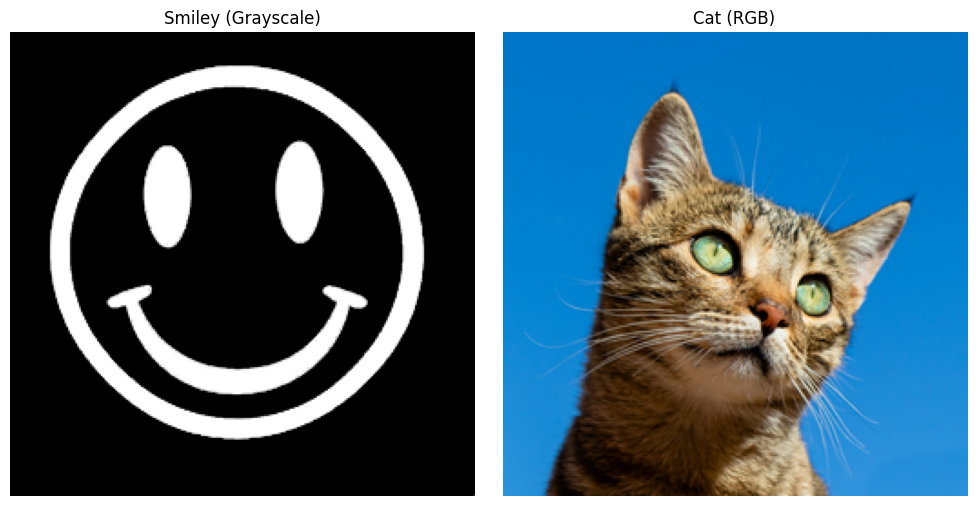

In [31]:
# Load and prepare images for reconstruction
def load_and_prepare_images():
    # Load grayscale smiley image (already 256x256)
    smiley_path = "/home/karthik/assignment-3-karthikvmala-main/dataset/Q2/smiley.png"
    smiley_img = Image.open(smiley_path).convert('L')  # Convert to grayscale
    smiley_array = np.array(smiley_img, dtype=np.float32) / 255.0  # Normalize to [0,1]
    
    # Load RGB cat image and resize to 256x256
    cat_path = "/home/karthik/assignment-3-karthikvmala-main/dataset/Q2/cat.jpg"
    cat_img = Image.open(cat_path).convert('RGB')
    cat_img = cat_img.resize((256, 256), Image.Resampling.LANCZOS)
    cat_array = np.array(cat_img, dtype=np.float32) / 255.0  # Normalize to [0,1]
    
    print(f"Smiley shape: {smiley_array.shape}, range: [{smiley_array.min():.3f}, {smiley_array.max():.3f}]")
    print(f"Cat shape: {cat_array.shape}, range: [{cat_array.min():.3f}, {cat_array.max():.3f}]")
    
    return smiley_array, cat_array

# Load images
smiley_img, cat_img = load_and_prepare_images()

# Visualize the images
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(smiley_img, cmap='gray')
axes[0].set_title('Smiley (Grayscale)')
axes[0].axis('off')

axes[1].imshow(cat_img)
axes[1].set_title('Cat (RGB)')
axes[1].axis('off')

plt.tight_layout()
plt.show()


In [32]:
# Feature Mapping Classes - Updated to match specifications

def get_raw(coords):
    """
    Raw mapping: γ_raw(x, y) = (x, y)
    Returns coordinates directly without any transformation
    """
    return coords

def get_polynomial(coords, order=5):
    """
    Polynomial expansion (Taylor-inspired): γ_poly(x, y) = [x, y, x², y², xy, ..., x^order, y^order]
    Expands into [x, y, x², y², xy, ..., x^order, y^order]
    """
    x = coords[:, 0:1]  # (N, 1)
    y = coords[:, 1:2]  # (N, 1)
    
    features = []
    
    # Add original coordinates
    features.append(x)  # x
    features.append(y)  # y
    
    # Add polynomial terms up to order
    for k in range(2, order + 1):
        features.append(x ** k)  # x^k
        features.append(y ** k)  # y^k
    
    # Add cross term xy
    features.append(x * y)  # xy
    
    return np.concatenate(features, axis=1)

def get_fourier(coords, freq=10):
    """
    Practical Fourier feature approximation: γ_fourier(x, y) = [1, sin(2πf₁x), cos(2πf₁x), ..., sin(2πfₖx), cos(2πfₖx), sin(2πf₁y), cos(2πf₁y), ..., sin(2πfₖy), cos(2πfₖy)]
    Avoids cross-term combinatorial explosion by treating x and y independently
    """
    x = coords[:, 0:1]  # (N, 1)
    y = coords[:, 1:2]  # (N, 1)
    
    features = []
    
    # Add bias term
    features.append(np.ones((coords.shape[0], 1)))  # 1
    
    # Generate frequencies
    frequencies = np.arange(1, freq + 1, dtype=np.float32)
    
    # Add x terms: sin(2πf₁x), cos(2πf₁x), ..., sin(2πfₖx), cos(2πfₖx)
    for f in frequencies:
        features.append(np.sin(2 * np.pi * f * x))
        features.append(np.cos(2 * np.pi * f * x))
    
    # Add y terms: sin(2πf₁y), cos(2πf₁y), ..., sin(2πfₖy), cos(2πfₖy)
    for f in frequencies:
        features.append(np.sin(2 * np.pi * f * y))
        features.append(np.cos(2 * np.pi * f * y))
    
    return np.concatenate(features, axis=1)

# Wrapper classes for consistency with existing code
class FeatureMapping:
    """Base class for feature mappings"""
    def __init__(self):
        pass
    
    def __call__(self, coords: np.ndarray) -> np.ndarray:
        raise NotImplementedError
    
    def get_output_dim(self, input_dim: int) -> int:
        raise NotImplementedError

class RawMapping(FeatureMapping):
    """Raw pixel coordinates - no transformation"""
    def __init__(self):
        super().__init__()
    
    def __call__(self, coords: np.ndarray) -> np.ndarray:
        return get_raw(coords)
    
    def get_output_dim(self, input_dim: int) -> int:
        return input_dim

class PolynomialMapping(FeatureMapping):
    """Polynomial expansion (Taylor-inspired)"""
    def __init__(self, order: int = 5):
        super().__init__()
        self.order = order
    
    def __call__(self, coords: np.ndarray) -> np.ndarray:
        return get_polynomial(coords, self.order)
    
    def get_output_dim(self, input_dim: int) -> int:
        # [x, y, x², y², xy, x³, y³, x⁴, y⁴, x⁵, y⁵, ...]
        # 2 (x,y) + 2*(order-1) (x²,y² to x^order,y^order) + 1 (xy) = 2*order + 1
        return 2 * self.order + 1

class FourierMapping(FeatureMapping):
    """Practical Fourier feature approximation"""
    def __init__(self, freq: int = 10):
        super().__init__()
        self.freq = freq
    
    def __call__(self, coords: np.ndarray) -> np.ndarray:
        return get_fourier(coords, self.freq)
    
    def get_output_dim(self, input_dim: int) -> int:
        # 1 (bias) + 2*freq (x terms) + 2*freq (y terms) = 1 + 4*freq
        return 1 + 4 * self.freq

# Test the feature mappings
def test_feature_mappings():
    # Create sample 2D coordinates
    coords = np.array([[0.0, 0.0], [0.5, 0.5], [1.0, 1.0]], dtype=np.float32)
    
    # Test each mapping
    raw_features = get_raw(coords)
    poly_features = get_polynomial(coords, order=3)
    fourier_features = get_fourier(coords, freq=3)
    
    print("Input coordinates shape:", coords.shape)
    print("Raw features shape:", raw_features.shape)
    print("Polynomial features shape:", poly_features.shape)
    print("Fourier features shape:", fourier_features.shape)
    
    print("\nInput coordinates:")
    print(coords)
    
    print("\nRaw features (should be same as input):")
    print(raw_features)
    
    print("\nPolynomial features (order=3):")
    print("Features: [x, y, x², y², xy, x³, y³]")
    print(poly_features[0])  # First sample
    
    print("\nFourier features (freq=3):")
    print("Features: [1, sin(2πx), cos(2πx), sin(4πx), cos(4πx), sin(6πx), cos(6πx), sin(2πy), cos(2πy), sin(4πy), cos(4πy), sin(6πy), cos(6πy)]")
    print(fourier_features[0])  # First sample

test_feature_mappings()


Input coordinates shape: (3, 2)
Raw features shape: (3, 2)
Polynomial features shape: (3, 7)
Fourier features shape: (3, 13)

Input coordinates:
[[0.  0. ]
 [0.5 0.5]
 [1.  1. ]]

Raw features (should be same as input):
[[0.  0. ]
 [0.5 0.5]
 [1.  1. ]]

Polynomial features (order=3):
Features: [x, y, x², y², xy, x³, y³]
[0. 0. 0. 0. 0. 0. 0.]

Fourier features (freq=3):
Features: [1, sin(2πx), cos(2πx), sin(4πx), cos(4πx), sin(6πx), cos(6πx), sin(2πy), cos(2πy), sin(4πy), cos(4πy), sin(6πy), cos(6πy)]
[1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1.]


In [33]:
# Dataset creation and training utilities
def create_image_dataset(img_array: np.ndarray):
    """
    Create dataset from image array
    Returns: (coordinates, pixel_values)
    - coordinates: (H*W, 2) normalized to [0,1]
    - pixel_values: (H*W, C) where C is number of channels
    """
    H, W = img_array.shape[:2]
    
    # Create coordinate grid
    y_coords, x_coords = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')
    
    # Normalize coordinates to [0,1]
    coords = np.stack([
        x_coords.flatten() / (W - 1),
        y_coords.flatten() / (H - 1)
    ], axis=1).astype(np.float32)
    
    # Flatten pixel values
    if img_array.ndim == 2:  # Grayscale
        pixels = img_array.flatten().reshape(-1, 1)
    else:  # RGB
        pixels = img_array.reshape(-1, img_array.shape[2])
    
    return coords, pixels

def train_reconstruction_model(model: Model, coords: np.ndarray, pixels: np.ndarray, 
                             feature_mapping: FeatureMapping, epochs: int = 1000, 
                             batch_size: int = 1024, lr: float = 1e-3):
    """
    Train model for image reconstruction
    """
    print(f"Training with {feature_mapping.__class__.__name__}")
    print(f"Input features: {feature_mapping.get_output_dim(2)}")
    print(f"Output channels: {pixels.shape[1]}")
    
    losses = []
    
    for epoch in range(epochs):
        # Shuffle data
        indices = np.random.permutation(len(coords))
        epoch_loss = 0
        num_batches = 0
        
        for i in range(0, len(coords), batch_size):
            batch_indices = indices[i:i + batch_size]
            batch_coords = coords[batch_indices]
            batch_pixels = pixels[batch_indices]
            
            # Apply feature mapping
            batch_features = feature_mapping(batch_coords)
            
            # Train step
            model.zero_grad()
            loss, _ = model.train(batch_features, batch_pixels)
            model.update()
            
            epoch_loss += float(loss)
            num_batches += 1
        
        avg_loss = epoch_loss / num_batches
        losses.append(avg_loss)
        
        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.6f}")
    
    return losses

def reconstruct_image(model: Model, feature_mapping: FeatureMapping, 
                     H: int, W: int, output_channels: int = 1):
    """
    Reconstruct image using trained model
    """
    # Create coordinate grid
    y_coords, x_coords = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')
    coords = np.stack([
        x_coords.flatten() / (W - 1),
        y_coords.flatten() / (H - 1)
    ], axis=1).astype(np.float32)
    
    # Apply feature mapping
    features = feature_mapping(coords)
    
    # Predict pixels
    with model.zero_grad():  # No gradients needed for inference
        predictions = model.predict(features)
    
    # Reshape to image
    reconstructed = predictions.reshape(H, W, output_channels)
    
    return reconstructed

# Test dataset creation
print("Testing dataset creation:")
smiley_coords, smiley_pixels = create_image_dataset(smiley_img)
cat_coords, cat_pixels = create_image_dataset(cat_img)

print(f"Smiley - Coords shape: {smiley_coords.shape}, Pixels shape: {smiley_pixels.shape}")
print(f"Cat - Coords shape: {cat_coords.shape}, Pixels shape: {cat_pixels.shape}")
print(f"Smiley pixel range: [{smiley_pixels.min():.3f}, {smiley_pixels.max():.3f}]")
print(f"Cat pixel range: [{cat_pixels.min():.3f}, {cat_pixels.max():.3f}]")


Testing dataset creation:
Smiley - Coords shape: (65536, 2), Pixels shape: (65536, 1)
Cat - Coords shape: (65536, 2), Pixels shape: (65536, 3)
Smiley pixel range: [0.000, 1.000]
Cat pixel range: [0.000, 1.000]


In [34]:
# Modular Data Loader with Normalization
class ModularDataLoader:
    """
    Modular data loader that handles different feature mappings with appropriate normalization
    """
    def __init__(self, img_path: str, image_type: str, method: str, order: int = 5, freq: int = 10):
        """
        Args:
            img_path: path to the image (RGB or grayscale)
            image_type: either "RGB" or "Gray"
            method: feature mapping to use ("Raw", "Polynomial", or "Fourier")
            order: order of polynomial expansion (if using Polynomial)
            freq: number of Fourier frequencies (if using Fourier)
        """
        self.img_path = img_path
        self.image_type = image_type.upper()
        self.method = method.upper()
        self.order = order
        self.freq = freq
        
        # Load and prepare image
        self.img_array, self.coords, self.pixels = self._load_and_prepare_image()
        
        # Apply feature mapping with normalization
        self.features = self._apply_feature_mapping()
        
        print(f"DataLoader initialized:")
        print(f"  Image: {img_path}")
        print(f"  Type: {self.image_type}")
        print(f"  Method: {self.method}")
        print(f"  Order/Freq: {self.order if self.method == 'POLYNOMIAL' else self.freq}")
        print(f"  Image shape: {self.img_array.shape}")
        print(f"  Feature shape: {self.features.shape}")
        print(f"  Pixel shape: {self.pixels.shape}")
        print(f"  Feature range: [{self.features.min():.3f}, {self.features.max():.3f}]")
    
    def _load_and_prepare_image(self):
        """Load image and create coordinate-pixel pairs"""
        # Load image
        img = Image.open(self.img_path)
        
        if self.image_type == "RGB":
            img = img.convert('RGB')
            img = img.resize((256, 256), Image.Resampling.LANCZOS)
        elif self.image_type == "GRAY":
            img = img.convert('L')
            if img.size != (256, 256):
                img = img.resize((256, 256), Image.Resampling.LANCZOS)
        else:
            raise ValueError("image_type must be 'RGB' or 'Gray'")
        
        # Convert to numpy array and normalize to [0,1]
        img_array = np.array(img, dtype=np.float32) / 255.0
        
        # Create coordinate grid
        H, W = img_array.shape[:2]
        y_coords, x_coords = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')
        
        # Normalize coordinates to [0,1] for all methods
        coords = np.stack([
            x_coords.flatten() / (W - 1),
            y_coords.flatten() / (H - 1)
        ], axis=1).astype(np.float32)
        
        # Flatten pixel values
        if img_array.ndim == 2:  # Grayscale
            pixels = img_array.flatten().reshape(-1, 1)
        else:  # RGB
            pixels = img_array.reshape(-1, img_array.shape[2])
        
        return img_array, coords, pixels
    
    def _apply_feature_mapping(self):
        """Apply the specified feature mapping with appropriate normalization"""
        if self.method == "RAW":
            # Raw features: coordinates already in [0,1], no additional normalization needed
            features = get_raw(self.coords)
            
        elif self.method == "POLYNOMIAL":
            # Polynomial features: apply normalization to prevent exploding values
            features = get_polynomial(self.coords, order=self.order)
            
            # Normalize polynomial features to [0,1] range
            # This prevents higher-order terms from dominating
            features_min = features.min(axis=0, keepdims=True)
            features_max = features.max(axis=0, keepdims=True)
            features_range = features_max - features_min
            features_range[features_range == 0] = 1  # Avoid division by zero
            features = (features - features_min) / features_range
            
        elif self.method == "FOURIER":
            # Fourier features: scale coordinates to cover appropriate frequency range
            # Scale coordinates to [0, 2π] to cover one full cycle for the highest frequency
            scaled_coords = self.coords * 2 * np.pi
            features = get_fourier(scaled_coords, freq=self.freq)
            
            # Fourier features (sin/cos) are already in [-1, 1], but we can normalize to [0,1]
            features = (features + 1) / 2
            
        else:
            raise ValueError(f"Unknown method: {self.method}. Must be 'Raw', 'Polynomial', or 'Fourier'")
        
        return features
    
    def get_data(self):
        """Return features and pixels for training"""
        return self.features, self.pixels
    
    def get_original_image(self):
        """Return the original image array"""
        return self.img_array
    
    def get_coords(self):
        """Return the coordinate grid"""
        return self.coords
    
    def get_feature_dim(self):
        """Return the dimensionality of the feature space"""
        return self.features.shape[1]
    
    def get_output_dim(self):
        """Return the dimensionality of the output (number of channels)"""
        return self.pixels.shape[1]

# Test the modular data loader
def test_modular_data_loader():
    print("Testing Modular Data Loader:")
    print("=" * 50)
    
    # Test with smiley image (grayscale)
    smiley_path = "/home/karthik/assignment-3-karthikvmala-main/dataset/Q2/smiley.png"
    
    # Test Raw mapping
    raw_loader = ModularDataLoader(smiley_path, "Gray", "Raw")
    raw_features, raw_pixels = raw_loader.get_data()
    
    # Test Polynomial mapping
    poly_loader = ModularDataLoader(smiley_path, "Gray", "Polynomial", order=3)
    poly_features, poly_pixels = poly_loader.get_data()
    
    # Test Fourier mapping
    fourier_loader = ModularDataLoader(smiley_path, "Gray", "Fourier", freq=5)
    fourier_features, fourier_pixels = fourier_loader.get_data()
    
    print(f"\nFeature dimensions:")
    print(f"  Raw: {raw_loader.get_feature_dim()}")
    print(f"  Polynomial (order=3): {poly_loader.get_feature_dim()}")
    print(f"  Fourier (freq=5): {fourier_loader.get_feature_dim()}")
    
    print(f"\nOutput dimensions:")
    print(f"  Raw: {raw_loader.get_output_dim()}")
    print(f"  Polynomial: {poly_loader.get_output_dim()}")
    print(f"  Fourier: {fourier_loader.get_output_dim()}")
    
    print(f"\nFeature ranges after normalization:")
    print(f"  Raw: [{raw_features.min():.3f}, {raw_features.max():.3f}]")
    print(f"  Polynomial: [{poly_features.min():.3f}, {poly_features.max():.3f}]")
    print(f"  Fourier: [{fourier_features.min():.3f}, {fourier_features.max():.3f}]")

test_modular_data_loader()


Testing Modular Data Loader:
DataLoader initialized:
  Image: /home/karthik/assignment-3-karthikvmala-main/dataset/Q2/smiley.png
  Type: GRAY
  Method: RAW
  Order/Freq: 10
  Image shape: (256, 256)
  Feature shape: (65536, 2)
  Pixel shape: (65536, 1)
  Feature range: [0.000, 1.000]
DataLoader initialized:
  Image: /home/karthik/assignment-3-karthikvmala-main/dataset/Q2/smiley.png
  Type: GRAY
  Method: POLYNOMIAL
  Order/Freq: 3
  Image shape: (256, 256)
  Feature shape: (65536, 7)
  Pixel shape: (65536, 1)
  Feature range: [0.000, 1.000]
DataLoader initialized:
  Image: /home/karthik/assignment-3-karthikvmala-main/dataset/Q2/smiley.png
  Type: GRAY
  Method: FOURIER
  Order/Freq: 5
  Image shape: (256, 256)
  Feature shape: (65536, 21)
  Pixel shape: (65536, 1)
  Feature range: [0.000, 1.000]

Feature dimensions:
  Raw: 2
  Polynomial (order=3): 7
  Fourier (freq=5): 21

Output dimensions:
  Raw: 1
  Polynomial: 1
  Fourier: 1

Feature ranges after normalization:
  Raw: [0.000, 1.00

In [35]:
# Updated training utilities to work with ModularDataLoader
def train_reconstruction_with_loader(data_loader: ModularDataLoader, epochs: int = 1000, 
                                   batch_size: int = 1024, lr: float = 1e-3, 
                                   hidden_width: int = 256, hidden_depth: int = 4):
    """
    Train reconstruction model using ModularDataLoader
    """
    features, pixels = data_loader.get_data()
    feature_dim = data_loader.get_feature_dim()
    output_dim = data_loader.get_output_dim()
    
    print(f"Training {data_loader.method} reconstruction model:")
    print(f"  Feature dimension: {feature_dim}")
    print(f"  Output dimension: {output_dim}")
    print(f"  Hidden layers: {hidden_depth} x {hidden_width}")
    print(f"  Learning rate: {lr}")
    print(f"  Batch size: {batch_size}")
    print(f"  Epochs: {epochs}")
    
    # Build model
    layers = []
    
    # Input layer
    layers.append(Linear(feature_dim, hidden_width, ReLU()))
    
    # Hidden layers
    for _ in range(hidden_depth - 1):
        layers.append(Linear(hidden_width, hidden_width, ReLU()))
    
    # Output layer (no activation for regression)
    layers.append(Linear(hidden_width, output_dim, Identity()))
    
    model = Model(layers, loss="mse", lr=lr)
    
    # Training loop
    losses = []
    
    for epoch in range(epochs):
        # Shuffle data
        indices = np.random.permutation(len(features))
        epoch_loss = 0
        num_batches = 0
        
        for i in range(0, len(features), batch_size):
            batch_indices = indices[i:i + batch_size]
            batch_features = features[batch_indices]
            batch_pixels = pixels[batch_indices]
            
            # Train step
            model.zero_grad()
            loss, _ = model.train(batch_features, batch_pixels)
            model.update()
            
            epoch_loss += float(loss)
            num_batches += 1
        
        avg_loss = epoch_loss / num_batches
        losses.append(avg_loss)
        
        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.6f}")
    
    return model, losses

def reconstruct_with_loader(model: Model, data_loader: ModularDataLoader):
    """
    Reconstruct image using trained model and data loader
    """
    features, _ = data_loader.get_data()
    original_img = data_loader.get_original_image()
    
    # Predict pixels
    with model.zero_grad():  # No gradients needed for inference
        predictions = model.predict(features)
    
    # Reshape to image
    H, W = original_img.shape[:2]
    output_channels = data_loader.get_output_dim()
    reconstructed = predictions.reshape(H, W, output_channels)
    
    # Clip to valid range [0,1]
    reconstructed = np.clip(reconstructed, 0, 1)
    
    return reconstructed

def visualize_reconstruction(original_img: np.ndarray, reconstructed_img: np.ndarray, 
                           method: str, loss_history: list = None):
    """
    Visualize original and reconstructed images
    """
    fig, axes = plt.subplots(1, 3 if loss_history is not None else 2, figsize=(12, 4))
    
    # Original image
    if original_img.ndim == 2:  # Grayscale
        axes[0].imshow(original_img, cmap='gray')
    else:  # RGB
        axes[0].imshow(original_img)
    axes[0].set_title('Original')
    axes[0].axis('off')
    
    # Reconstructed image
    if reconstructed_img.ndim == 2:  # Grayscale
        axes[1].imshow(reconstructed_img, cmap='gray')
    else:  # RGB
        axes[1].imshow(reconstructed_img)
    axes[1].set_title(f'Reconstructed ({method})')
    axes[1].axis('off')
    
    # Loss curve (if provided)
    if loss_history is not None:
        axes[2].plot(loss_history)
        axes[2].set_title('Training Loss')
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('MSE Loss')
        axes[2].set_yscale('log')
    
    plt.tight_layout()
    plt.show()
    
    # Calculate and display metrics
    mse = np.mean((original_img - reconstructed_img) ** 2)
    psnr = 20 * np.log10(1.0 / np.sqrt(mse)) if mse > 0 else float('inf')
    
    print(f"Reconstruction Metrics ({method}):")
    print(f"  MSE: {mse:.6f}")
    print(f"  PSNR: {psnr:.2f} dB")

# Test with a quick reconstruction
def quick_test():
    print("Quick reconstruction test:")
    print("=" * 40)
    
    # Test with smiley image using Raw mapping
    smiley_path = "/home/karthik/assignment-3-karthikvmala-main/dataset/Q2/smiley.png"
    raw_loader = ModularDataLoader(smiley_path, "Gray", "Raw")
    
    # Train with fewer epochs for quick test
    model, losses = train_reconstruction_with_loader(
        raw_loader, epochs=200, batch_size=1024, lr=1e-3, 
        hidden_width=128, hidden_depth=3
    )
    
    # Reconstruct
    reconstructed = reconstruct_with_loader(model, raw_loader)
    
    # Visualize
    visualize_reconstruction(
        raw_loader.get_original_image(), 
        reconstructed.squeeze(),  # Remove channel dimension for grayscale
        "Raw", 
        losses
    )

# Uncomment to run quick test
# quick_test()


In [36]:
# Comprehensive Training and Comparison Framework
import time
from PIL import Image as PILImage
import os

class ReconstructionExperiment:
    """
    Complete experiment framework for comparing feature mappings
    """
    def __init__(self, results_dir: str = "/home/karthik/assignment-3-karthikvmala-main/reconstruction_results"):
        self.results_dir = results_dir
        os.makedirs(results_dir, exist_ok=True)
        
        # Fixed architecture for fair comparison
        self.hidden_sizes = [64, 128, 128]
        self.epochs_config = {
            "smiley.png": 50,
            "cat.jpg": 150
        }
        
        # Test configurations
        self.polynomial_orders = [5, 15, 25]
        self.fourier_freqs = [5, 15, 25]
        
        self.results = {}
    
    def train_single_experiment(self, data_loader: ModularDataLoader, epochs: int, 
                              experiment_name: str, save_epoch_images: bool = True):
        """
        Train a single experiment and save results
        """
        print(f"\n{'='*60}")
        print(f"Training: {experiment_name}")
        print(f"{'='*60}")
        
        features, pixels = data_loader.get_data()
        feature_dim = data_loader.get_feature_dim()
        output_dim = data_loader.get_output_dim()
        
        # Build model with fixed architecture
        layers = []
        
        # Input layer
        layers.append(Linear(feature_dim, self.hidden_sizes[0], ReLU()))
        
        # Hidden layers
        for i in range(len(self.hidden_sizes) - 1):
            layers.append(Linear(self.hidden_sizes[i], self.hidden_sizes[i + 1], ReLU()))
        
        # Output layer
        layers.append(Linear(self.hidden_sizes[-1], output_dim, Identity()))
        
        model = Model(layers, loss="mse", lr=1e-3)
        
        # Training setup
        batch_size = 1024
        losses = []
        epoch_times = []
        epoch_images = []
        
        start_time = time.time()
        
        for epoch in range(epochs):
            epoch_start = time.time()
            
            # Shuffle data
            indices = np.random.permutation(len(features))
            epoch_loss = 0
            num_batches = 0
            
            for i in range(0, len(features), batch_size):
                batch_indices = indices[i:i + batch_size]
                batch_features = features[batch_indices]
                batch_pixels = pixels[batch_indices]
                
                # Train step
                model.zero_grad()
                loss, _ = model.train(batch_features, batch_pixels)
                model.update()
                
                epoch_loss += float(loss)
                num_batches += 1
            
            avg_loss = epoch_loss / num_batches
            losses.append(avg_loss)
            
            epoch_end = time.time()
            epoch_time = epoch_end - epoch_start
            epoch_times.append(epoch_time)
            
            # Save epoch image if requested
            if save_epoch_images:
                reconstructed = self._reconstruct_epoch_image(model, data_loader)
                epoch_images.append(reconstructed.copy())
            
            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.6f}, Time: {epoch_time:.2f}s")
        
        total_time = time.time() - start_time
        
        # Store results
        result = {
            'experiment_name': experiment_name,
            'method': data_loader.method,
            'feature_dim': feature_dim,
            'final_loss': losses[-1],
            'total_time': total_time,
            'avg_epoch_time': np.mean(epoch_times),
            'losses': losses,
            'epoch_times': epoch_times,
            'epoch_images': epoch_images if save_epoch_images else None,
            'model': model,
            'data_loader': data_loader
        }
        
        self.results[experiment_name] = result
        
        print(f"Completed: {experiment_name}")
        print(f"Final Loss: {losses[-1]:.6f}")
        print(f"Total Time: {total_time:.2f}s")
        print(f"Avg Epoch Time: {np.mean(epoch_times):.2f}s")
        
        return result
    
    def _reconstruct_epoch_image(self, model: Model, data_loader: ModularDataLoader):
        """Reconstruct image at current epoch"""
        features, _ = data_loader.get_data()
        original_img = data_loader.get_original_image()
        
        model.zero_grad()
        predictions = model.predict(features)
        
        H, W = original_img.shape[:2]
        output_channels = data_loader.get_output_dim()
        reconstructed = predictions.reshape(H, W, output_channels)
        reconstructed = np.clip(reconstructed, 0, 1)
        
        return reconstructed
    
    def run_full_experiment(self, img_path: str, image_type: str = "Gray"):
        """
        Run complete experiment for an image with all feature mappings
        """
        img_name = os.path.basename(img_path)
        epochs = self.epochs_config[img_name]
        
        print(f"\n{'='*80}")
        print(f"RUNNING FULL EXPERIMENT: {img_name}")
        print(f"Epochs: {epochs}")
        print(f"{'='*80}")
        
        # 1. Raw Features (Baseline)
        raw_loader = ModularDataLoader(img_path, image_type, "Raw")
        self.train_single_experiment(
            raw_loader, epochs, f"{img_name}_Raw", save_epoch_images=True
        )
        
        # 2. Polynomial Features
        for order in self.polynomial_orders:
            poly_loader = ModularDataLoader(img_path, image_type, "Polynomial", order=order)
            self.train_single_experiment(
                poly_loader, epochs, f"{img_name}_Polynomial_order{order}", save_epoch_images=True
            )
        
        # 3. Fourier Features
        for freq in self.fourier_freqs:
            fourier_loader = ModularDataLoader(img_path, image_type, "Fourier", freq=freq)
            self.train_single_experiment(
                fourier_loader, epochs, f"{img_name}_Fourier_freq{freq}", save_epoch_images=True
            )
        
        # Generate comparison table
        self._create_comparison_table(img_name)
        
        # Generate GIF for selected methods
        self._create_comparison_gif(img_name, ["Raw", "Polynomial_order15", "Fourier_freq15"])
    
    def _create_comparison_table(self, img_name: str):
        """Create comparison table for results"""
        print(f"\n{'='*80}")
        print(f"RESULTS TABLE: {img_name}")
        print(f"{'='*80}")
        
        # Filter results for this image
        img_results = {k: v for k, v in self.results.items() if k.startswith(img_name)}
        
        # Create table
        print(f"{'Method':<25} {'Final Loss':<12} {'Epoch Time':<12} {'Input Params':<12}")
        print("-" * 70)
        
        for exp_name, result in img_results.items():
            method = result['method']
            if 'order' in exp_name:
                method += f" (order={exp_name.split('order')[1]})"
            elif 'freq' in exp_name:
                method += f" (freq={exp_name.split('freq')[1]})"
            
            print(f"{method:<25} {result['final_loss']:<12.6f} {result['avg_epoch_time']:<12.2f} {result['feature_dim']:<12}")
        
        # Save table to file
        table_path = os.path.join(self.results_dir, f"{img_name}_comparison_table.txt")
        with open(table_path, 'w') as f:
            f.write(f"RESULTS TABLE: {img_name}\n")
            f.write("=" * 80 + "\n")
            f.write(f"{'Method':<25} {'Final Loss':<12} {'Epoch Time':<12} {'Input Params':<12}\n")
            f.write("-" * 70 + "\n")
            
            for exp_name, result in img_results.items():
                method = result['method']
                if 'order' in exp_name:
                    method += f" (order={exp_name.split('order')[1]})"
                elif 'freq' in exp_name:
                    method += f" (freq={exp_name.split('freq')[1]})"
                
                f.write(f"{method:<25} {result['final_loss']:<12.6f} {result['avg_epoch_time']:<12.2f} {result['feature_dim']:<12}\n")
        
        print(f"\nTable saved to: {table_path}")
    
    def _create_comparison_gif(self, img_name: str, selected_methods: list):
        """Create GIF comparing selected methods"""
        print(f"\nCreating comparison GIF for {img_name}...")
        
        # Get selected results
        gif_results = []
        for method in selected_methods:
            exp_name = f"{img_name}_{method}"
            if exp_name in self.results:
                gif_results.append(self.results[exp_name])
            else:
                print(f"Warning: {exp_name} not found in results")
                return
        
        if len(gif_results) != 3:
            print(f"Error: Need exactly 3 results for GIF, got {len(gif_results)}")
            return
        
        # Create GIF frames
        frames = []
        max_epochs = min(len(r['epoch_images']) for r in gif_results)
        
        for epoch in range(max_epochs):
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            
            for i, (result, method) in enumerate(zip(gif_results, selected_methods)):
                # Get epoch image
                epoch_img = result['epoch_images'][epoch]
                
                # Display image
                if epoch_img.ndim == 2:  # Grayscale
                    axes[i].imshow(epoch_img, cmap='gray')
                else:  # RGB
                    axes[i].imshow(epoch_img)
                
                # Add title with loss
                current_loss = result['losses'][epoch]
                axes[i].set_title(f'{method}\nLoss: {current_loss:.6f}')
                axes[i].axis('off')
            
            plt.suptitle(f'Epoch {epoch + 1}/{max_epochs}', fontsize=16)
            plt.tight_layout()
            
            # Convert to PIL Image
            fig.canvas.draw()
            buf = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
            buf = buf.reshape(fig.canvas.get_width_height()[::-1] + (3,))
            frames.append(PILImage.fromarray(buf))
            
            plt.close(fig)
        
        # Save GIF
        gif_path = os.path.join(self.results_dir, f"{img_name}_comparison.gif")
        frames[0].save(
            gif_path,
            save_all=True,
            append_images=frames[1:],
            duration=500,  # 500ms per frame
            loop=0
        )
        
        print(f"GIF saved to: {gif_path}")
    
    def plot_loss_comparison(self, img_name: str):
        """Plot loss curves for all methods"""
        img_results = {k: v for k, v in self.results.items() if k.startswith(img_name)}
        
        plt.figure(figsize=(12, 8))
        
        for exp_name, result in img_results.items():
            method = result['method']
            if 'order' in exp_name:
                method += f" (order={exp_name.split('order')[1]})"
            elif 'freq' in exp_name:
                method += f" (freq={exp_name.split('freq')[1]})"
            
            plt.plot(result['losses'], label=method, linewidth=2)
        
        plt.xlabel('Epoch')
        plt.ylabel('MSE Loss')
        plt.title(f'Loss Comparison: {img_name}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.yscale('log')
        
        plt.tight_layout()
        
        # Save plot
        plot_path = os.path.join(self.results_dir, f"{img_name}_loss_comparison.png")
        plt.savefig(plot_path, dpi=150, bbox_inches='tight')
        plt.show()
        
        print(f"Loss comparison plot saved to: {plot_path}")

# Example usage
def run_experiments():
    """Run experiments for both images"""
    experiment = ReconstructionExperiment()
    
    # Run experiment for smiley (grayscale)
    smiley_path = "/home/karthik/assignment-3-karthikvmala-main/dataset/Q2/smiley.png"
    experiment.run_full_experiment(smiley_path, "Gray")
    experiment.plot_loss_comparison("smiley.png")
    
    # Run experiment for cat (RGB)
    cat_path = "/home/karthik/assignment-3-karthikvmala-main/dataset/Q2/cat.jpg"
    experiment.run_full_experiment(cat_path, "RGB")
    experiment.plot_loss_comparison("cat.jpg")
    
    return experiment

# Uncomment to run full experiments (this will take a while!)
# experiment = run_experiments()


Running Quick Demo with Reduced Parameters

RUNNING FULL EXPERIMENT: smiley.png
Epochs: 20
DataLoader initialized:
  Image: /home/karthik/assignment-3-karthikvmala-main/dataset/Q2/smiley.png
  Type: GRAY
  Method: RAW
  Order/Freq: 10
  Image shape: (256, 256)
  Feature shape: (65536, 2)
  Pixel shape: (65536, 1)
  Feature range: [0.000, 1.000]

Training: smiley.png_Raw
Epoch 10/20, Loss: 0.135219, Time: 0.50s
Epoch 20/20, Loss: 0.134849, Time: 0.25s
Completed: smiley.png_Raw
Final Loss: 0.134849
Total Time: 8.18s
Avg Epoch Time: 0.29s
DataLoader initialized:
  Image: /home/karthik/assignment-3-karthikvmala-main/dataset/Q2/smiley.png
  Type: GRAY
  Method: POLYNOMIAL
  Order/Freq: 5
  Image shape: (256, 256)
  Feature shape: (65536, 11)
  Pixel shape: (65536, 1)
  Feature range: [0.000, 1.000]

Training: smiley.png_Polynomial_order5
Epoch 10/20, Loss: 0.134569, Time: 0.31s
Epoch 20/20, Loss: 0.132282, Time: 0.19s
Completed: smiley.png_Polynomial_order5
Final Loss: 0.132282
Total Time: 

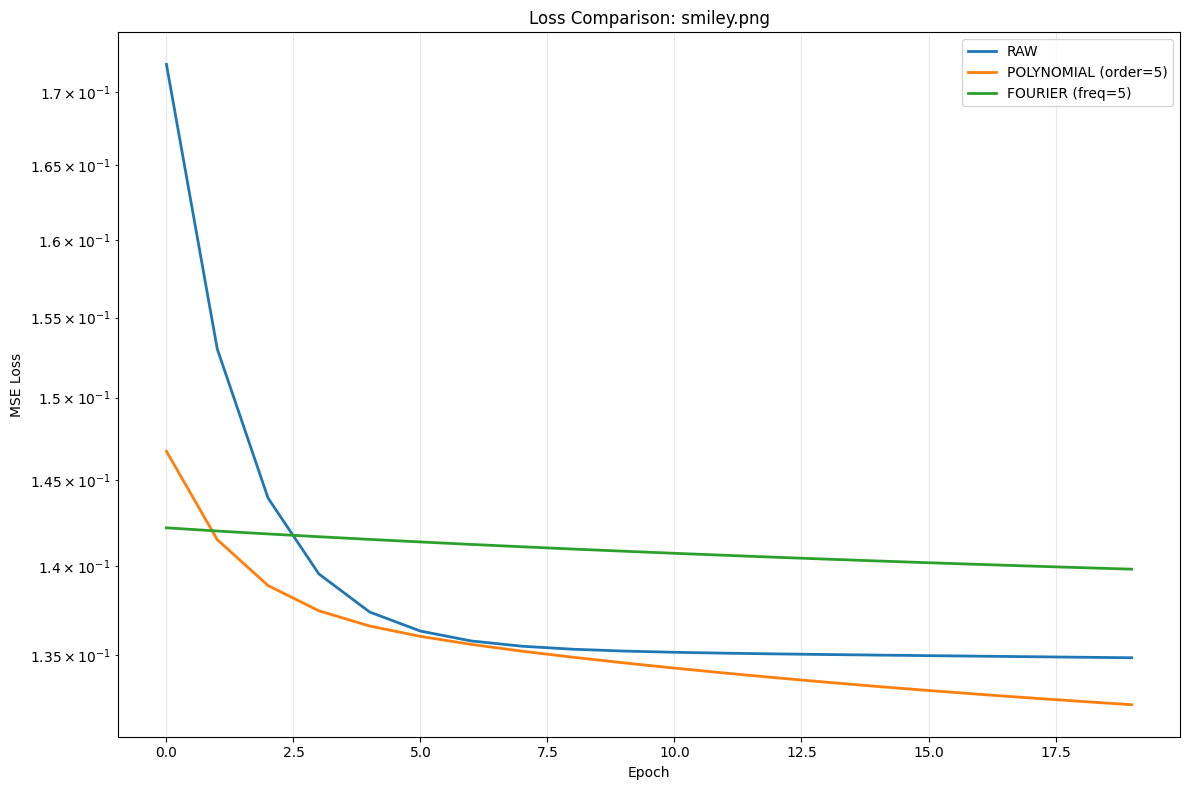

Loss comparison plot saved to: /home/karthik/assignment-3-karthikvmala-main/reconstruction_results/smiley.png_loss_comparison.png


In [37]:


# Quick demo with reduced parameters for faster testing
def run_quick_demo():
    """Run a quick demo with reduced parameters"""
    print("Running Quick Demo with Reduced Parameters")
    print("=" * 50)
    
    # Create experiment with reduced parameters
    experiment = ReconstructionExperiment()
    experiment.polynomial_orders = [5]  # Just one polynomial order
    experiment.fourier_freqs = [5]      # Just one Fourier frequency
    experiment.epochs_config = {
        "smiley.png": 20,  # Reduced epochs for demo
        "cat.jpg": 30
    }
    
    # Run demo for smiley only
    smiley_path = "/home/karthik/assignment-3-karthikvmala-main/dataset/Q2/smiley.png"
    experiment.run_full_experiment(smiley_path, "Gray")
    experiment.plot_loss_comparison("smiley.png")
    
    return experiment

# Run the quick demo
demo_experiment = run_quick_demo()


In [38]:
# Blurred Images Reconstruction Analysis
class BlurredImageExperiment:
    """
    Experiment framework for analyzing reconstruction performance on blurred images
    """
    def __init__(self, blurred_dir: str = "/home/karthik/assignment-3-karthikvmala-main/dataset/Q2/blurred"):
        self.blurred_dir = blurred_dir
        self.results = {}
        
        # Training configuration
        self.max_epochs = 100
        self.hidden_sizes = [64, 128, 128]
        self.lr = 1e-3
        self.batch_size = 1024
        
        # Early stopping parameters
        self.patience = 10
        self.rel_improve_threshold = 0.01
    
    def load_blurred_images(self):
        """Load all blurred images (blur_0.png to blur_10.png)"""
        blurred_images = {}
        
        for blur_level in range(11):  # 0 to 10
            img_path = os.path.join(self.blurred_dir, f"blur_{blur_level}.png")
            
            if os.path.exists(img_path):
                img = Image.open(img_path).convert('RGB')
                img = img.resize((256, 256), Image.Resampling.LANCZOS)
                img_array = np.array(img, dtype=np.float32) / 255.0
                blurred_images[blur_level] = img_array
                print(f"Loaded blur_{blur_level}.png: shape {img_array.shape}")
            else:
                print(f"Warning: {img_path} not found")
        
        return blurred_images
    
    def train_with_early_stopping(self, data_loader: ModularDataLoader, method_name: str, 
                                 blur_level: int, max_epochs: int = 100):
        """Train model with early stopping"""
        features, pixels = data_loader.get_data()
        feature_dim = data_loader.get_feature_dim()
        output_dim = data_loader.get_output_dim()
        
        # Build model
        layers = []
        layers.append(Linear(feature_dim, self.hidden_sizes[0], ReLU()))
        for i in range(len(self.hidden_sizes) - 1):
            layers.append(Linear(self.hidden_sizes[i], self.hidden_sizes[i + 1], ReLU()))
        layers.append(Linear(self.hidden_sizes[-1], output_dim, Identity()))
        
        model = Model(layers, loss="mse", lr=self.lr)
        
        # Training with early stopping
        losses = []
        best_loss = float('inf')
        epochs_without_improvement = 0
        
        for epoch in range(max_epochs):
            # Shuffle data
            indices = np.random.permutation(len(features))
            epoch_loss = 0
            num_batches = 0
            
            for i in range(0, len(features), self.batch_size):
                batch_indices = indices[i:i + self.batch_size]
                batch_features = features[batch_indices]
                batch_pixels = pixels[batch_indices]
                
                model.zero_grad()
                loss, _ = model.train(batch_features, batch_pixels)
                model.update()
                
                epoch_loss += float(loss)
                num_batches += 1
            
            avg_loss = epoch_loss / num_batches
            losses.append(avg_loss)
            
            # Early stopping check
            if avg_loss < best_loss * (1 - self.rel_improve_threshold):
                best_loss = avg_loss
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1
            
            if (epoch + 1) % 20 == 0:
                print(f"  Epoch {epoch + 1}/{max_epochs}, Loss: {avg_loss:.6f}")
            
            if epochs_without_improvement >= self.patience and epoch >= self.patience:
                print(f"  Early stopping at epoch {epoch + 1}")
                break
        
        # Reconstruct final image
        reconstructed = self._reconstruct_image(model, data_loader)
        
        result = {
            'method': method_name,
            'blur_level': blur_level,
            'final_loss': losses[-1],
            'best_loss': best_loss,
            'epochs_trained': len(losses),
            'losses': losses,
            'model': model,
            'reconstructed': reconstructed,
            'original': data_loader.get_original_image()
        }
        
        return result
    
    def _reconstruct_image(self, model: Model, data_loader: ModularDataLoader):
        """Reconstruct image using trained model"""
        features, _ = data_loader.get_data()
        original_img = data_loader.get_original_image()
        
        model.zero_grad()  # Call zero_grad directly
        predictions = model.predict(features)
        
        H, W = original_img.shape[:2]
        output_channels = data_loader.get_output_dim()
        reconstructed = predictions.reshape(H, W, output_channels)
        reconstructed = np.clip(reconstructed, 0, 1)
        
        return reconstructed
    
    def run_blurred_experiment(self):
        """Run complete experiment on all blurred images"""
        print("Loading blurred images...")
        blurred_images = self.load_blurred_images()
        
        if not blurred_images:
            print("No blurred images found!")
            return
        
        print(f"\nStarting blurred image reconstruction experiment...")
        print(f"Found {len(blurred_images)} blurred images")
        
        # Create temporary files for each blurred image
        temp_dir = "/tmp/blurred_temp"
        os.makedirs(temp_dir, exist_ok=True)
        
        try:
            for blur_level, img_array in blurred_images.items():
                print(f"\n{'='*60}")
                print(f"Processing blur level {blur_level}")
                print(f"{'='*60}")
                
                # Save temporary image
                temp_path = os.path.join(temp_dir, f"blur_{blur_level}.png")
                temp_img = Image.fromarray((img_array * 255).astype(np.uint8))
                temp_img.save(temp_path)
                
                # Train BASE method (Raw coordinates)
                print(f"Training BASE method for blur level {blur_level}...")
                base_loader = ModularDataLoader(temp_path, "RGB", "Raw")
                base_result = self.train_with_early_stopping(
                    base_loader, "BASE", blur_level, self.max_epochs
                )
                
                # Train FOURIER method (frequency k=5)
                print(f"Training FOURIER method for blur level {blur_level}...")
                fourier_loader = ModularDataLoader(temp_path, "RGB", "Fourier", freq=5)
                fourier_result = self.train_with_early_stopping(
                    fourier_loader, "FOURIER", blur_level, self.max_epochs
                )
                
                # Store results
                self.results[blur_level] = {
                    'BASE': base_result,
                    'FOURIER': fourier_result
                }
                
                print(f"Blur level {blur_level} completed:")
                print(f"  BASE final loss: {base_result['final_loss']:.6f}")
                print(f"  FOURIER final loss: {fourier_result['final_loss']:.6f}")
        
        finally:
            # Clean up temporary files
            import shutil
            if os.path.exists(temp_dir):
                shutil.rmtree(temp_dir)
        
        print(f"\n{'='*60}")
        print("All experiments completed!")
        print(f"{'='*60}")
    
    def analyze_results(self):
        """Analyze and visualize results"""
        if not self.results:
            print("No results to analyze. Run experiment first.")
            return
        
        # Extract data for plotting
        blur_levels = sorted(self.results.keys())
        base_losses = [self.results[level]['BASE']['final_loss'] for level in blur_levels]
        fourier_losses = [self.results[level]['FOURIER']['final_loss'] for level in blur_levels]
        
        # Create comparison plots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Linear scale plot
        ax1.plot(blur_levels, base_losses, 'b-o', label='BASE (Raw)', linewidth=2, markersize=6)
        ax1.plot(blur_levels, fourier_losses, 'r-s', label='FOURIER (k=5)', linewidth=2, markersize=6)
        ax1.set_xlabel('Blur Level (σ)')
        ax1.set_ylabel('Final Reconstruction Loss')
        ax1.set_title('Reconstruction Loss vs Blur Level (Linear Scale)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Logarithmic scale plot
        ax2.plot(blur_levels, base_losses, 'b-o', label='BASE (Raw)', linewidth=2, markersize=6)
        ax2.plot(blur_levels, fourier_losses, 'r-s', label='FOURIER (k=5)', linewidth=2, markersize=6)
        ax2.set_xlabel('Blur Level (σ)')
        ax2.set_ylabel('Final Reconstruction Loss (log scale)')
        ax2.set_title('Reconstruction Loss vs Blur Level (Log Scale)')
        ax2.set_yscale('log')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Create detailed comparison table
        print(f"\n{'='*80}")
        print("DETAILED RESULTS TABLE")
        print(f"{'='*80}")
        print(f"{'Blur Level':<12} {'BASE Loss':<15} {'FOURIER Loss':<15} {'BASE Epochs':<12} {'FOURIER Epochs':<15}")
        print("-" * 80)
        
        for level in blur_levels:
            base_result = self.results[level]['BASE']
            fourier_result = self.results[level]['FOURIER']
            
            print(f"{level:<12} {base_result['final_loss']:<15.6f} {fourier_result['final_loss']:<15.6f} "
                  f"{base_result['epochs_trained']:<12} {fourier_result['epochs_trained']:<15}")
        
        # Save results
        self._save_results()
    
    def visualize_sample_reconstructions(self, blur_levels_to_show=[0, 3, 7, 10]):
        """Visualize original vs reconstructed images for selected blur levels"""
        if not self.results:
            print("No results to visualize. Run experiment first.")
            return
        
        fig, axes = plt.subplots(len(blur_levels_to_show), 4, figsize=(16, 4 * len(blur_levels_to_show)))
        
        if len(blur_levels_to_show) == 1:
            axes = axes.reshape(1, -1)
        
        for i, blur_level in enumerate(blur_levels_to_show):
            if blur_level not in self.results:
                continue
            
            base_result = self.results[blur_level]['BASE']
            fourier_result = self.results[blur_level]['FOURIER']
            
            # Original image
            axes[i, 0].imshow(base_result['original'])
            axes[i, 0].set_title(f'Original (σ={blur_level})')
            axes[i, 0].axis('off')
            
            # BASE reconstruction
            axes[i, 1].imshow(base_result['reconstructed'])
            axes[i, 1].set_title(f'BASE (Loss: {base_result["final_loss"]:.4f})')
            axes[i, 1].axis('off')
            
            # FOURIER reconstruction
            axes[i, 2].imshow(fourier_result['reconstructed'])
            axes[i, 2].set_title(f'FOURIER (Loss: {fourier_result["final_loss"]:.4f})')
            axes[i, 2].axis('off')
            
            # Loss curves
            axes[i, 3].plot(base_result['losses'], 'b-', label='BASE', linewidth=2)
            axes[i, 3].plot(fourier_result['losses'], 'r-', label='FOURIER', linewidth=2)
            axes[i, 3].set_xlabel('Epoch')
            axes[i, 3].set_ylabel('Loss')
            axes[i, 3].set_title('Training Curves')
            axes[i, 3].legend()
            axes[i, 3].grid(True, alpha=0.3)
            axes[i, 3].set_yscale('log')
        
        plt.tight_layout()
        plt.show()
    
    def _save_results(self):
        """Save results to file"""
        results_dir = "/home/karthik/assignment-3-karthikvmala-main/blurred_results"
        os.makedirs(results_dir, exist_ok=True)
        
        # Save detailed results
        results_file = os.path.join(results_dir, "blurred_experiment_results.txt")
        with open(results_file, 'w') as f:
            f.write("BLURRED IMAGE RECONSTRUCTION EXPERIMENT RESULTS\n")
            f.write("=" * 60 + "\n\n")
            
            for blur_level in sorted(self.results.keys()):
                f.write(f"Blur Level {blur_level}:\n")
                f.write("-" * 20 + "\n")
                
                for method in ['BASE', 'FOURIER']:
                    result = self.results[blur_level][method]
                    f.write(f"  {method}:\n")
                    f.write(f"    Final Loss: {result['final_loss']:.6f}\n")
                    f.write(f"    Best Loss: {result['best_loss']:.6f}\n")
                    f.write(f"    Epochs Trained: {result['epochs_trained']}\n")
                
                f.write("\n")
        
        print(f"Results saved to: {results_file}")

# Run the blurred image experiment
def run_blurred_experiment():
    """Run the complete blurred image experiment"""
    experiment = BlurredImageExperiment()
    
    print("Starting Blurred Image Reconstruction Experiment")
    print("=" * 60)
    
    # Run the experiment
    experiment.run_blurred_experiment()
    
    # Analyze results
    experiment.analyze_results()
    
    # Visualize sample reconstructions
    experiment.visualize_sample_reconstructions()
    
    return experiment

# Uncomment to run the experiment
# blurred_experiment = run_blurred_experiment()


Running Quick Blurred Image Demo
Loaded blur_0.png
Loaded blur_2.png
Loaded blur_5.png
Loaded blur_8.png

Running demo on 4 blur levels...

Processing blur level 0...
  Training BASE method...
DataLoader initialized:
  Image: /tmp/blurred_demo/blur_0.png
  Type: RGB
  Method: RAW
  Order/Freq: 10
  Image shape: (256, 256, 3)
  Feature shape: (65536, 2)
  Pixel shape: (65536, 3)
  Feature range: [0.000, 1.000]
  Epoch 20/30, Loss: 0.063038
  Training FOURIER method...
DataLoader initialized:
  Image: /tmp/blurred_demo/blur_0.png
  Type: RGB
  Method: FOURIER
  Order/Freq: 5
  Image shape: (256, 256, 3)
  Feature shape: (65536, 21)
  Pixel shape: (65536, 3)
  Feature range: [0.000, 1.000]
  Epoch 20/30, Loss: 0.066203
  Early stopping at epoch 28
  Completed - BASE: 0.0606, FOURIER: 0.0657

Processing blur level 2...
  Training BASE method...
DataLoader initialized:
  Image: /tmp/blurred_demo/blur_2.png
  Type: RGB
  Method: RAW
  Order/Freq: 10
  Image shape: (256, 256, 3)
  Feature sha

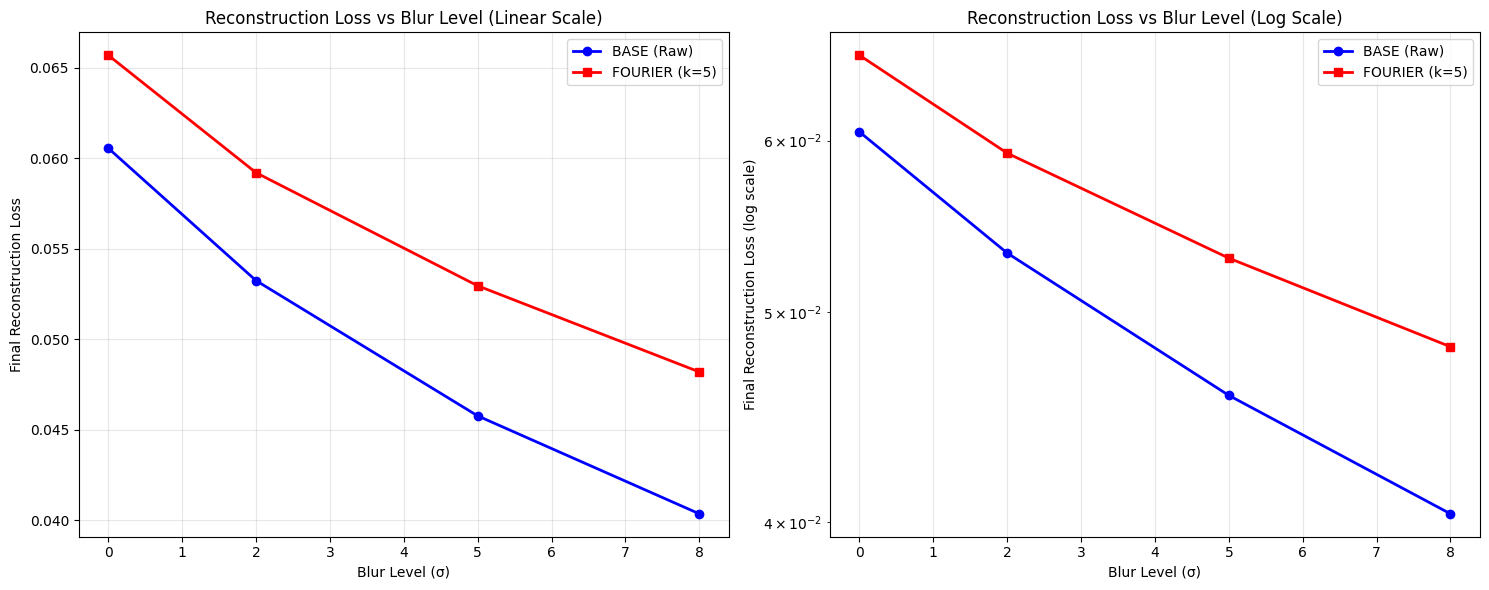


DETAILED RESULTS TABLE
Blur Level   BASE Loss       FOURIER Loss    BASE Epochs  FOURIER Epochs 
--------------------------------------------------------------------------------
0            0.060558        0.065694        30           28             
2            0.053245        0.059205        30           30             
5            0.045775        0.052959        30           30             
8            0.040366        0.048203        30           29             
Results saved to: /home/karthik/assignment-3-karthikvmala-main/blurred_results/blurred_experiment_results.txt


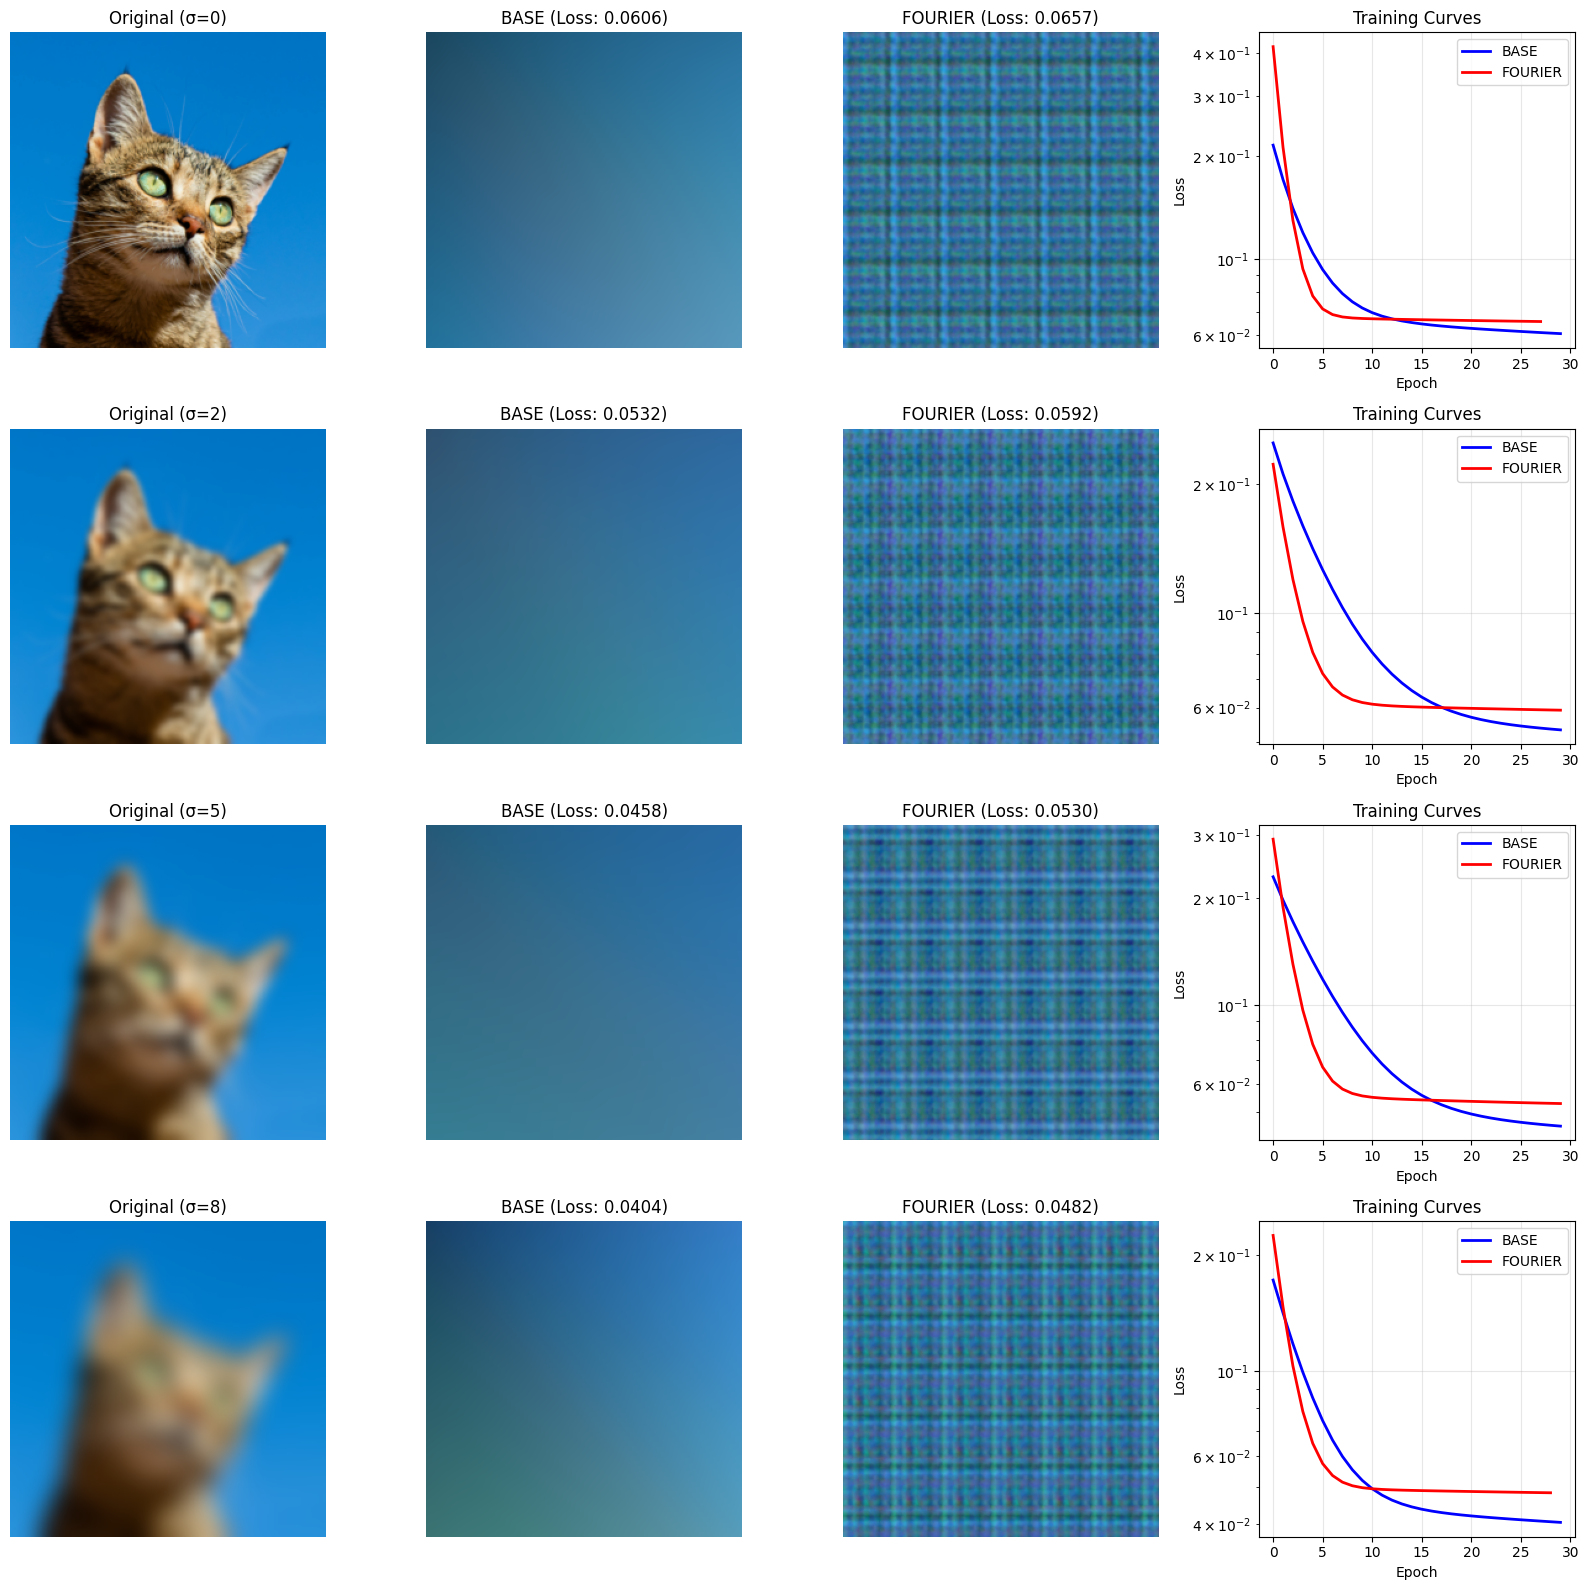

In [39]:
# Quick demo for blurred images (with reduced blur levels for faster testing)
def run_blurred_demo():
    """Run a quick demo with reduced blur levels"""
    print("Running Quick Blurred Image Demo")
    print("=" * 40)
    
    # Create experiment with reduced parameters
    experiment = BlurredImageExperiment()
    experiment.max_epochs = 30  # Reduced epochs for demo
    
    # Load just a few blurred images for demo
    blurred_images = {}
    demo_blur_levels = [0, 2, 5, 8, 10]  # Reduced set for demo
    
    for blur_level in demo_blur_levels:
        img_path = os.path.join(experiment.blurred_dir, f"blur_{blur_level}.png")
        
        if os.path.exists(img_path):
            img = Image.open(img_path).convert('RGB')
            img = img.resize((256, 256), Image.Resampling.LANCZOS)
            img_array = np.array(img, dtype=np.float32) / 255.0
            blurred_images[blur_level] = img_array
            print(f"Loaded blur_{blur_level}.png")
        else:
            print(f"Warning: {img_path} not found")
    
    if not blurred_images:
        print("No blurred images found for demo!")
        return None
    
    print(f"\nRunning demo on {len(blurred_images)} blur levels...")
    
    # Create temporary files and run experiments
    temp_dir = "/tmp/blurred_demo"
    os.makedirs(temp_dir, exist_ok=True)
    
    try:
        for blur_level, img_array in blurred_images.items():
            print(f"\nProcessing blur level {blur_level}...")
            
            # Save temporary image
            temp_path = os.path.join(temp_dir, f"blur_{blur_level}.png")
            temp_img = Image.fromarray((img_array * 255).astype(np.uint8))
            temp_img.save(temp_path)
            
            # Train BASE method
            print(f"  Training BASE method...")
            base_loader = ModularDataLoader(temp_path, "RGB", "Raw")
            base_result = experiment.train_with_early_stopping(
                base_loader, "BASE", blur_level, experiment.max_epochs
            )
            
            # Train FOURIER method
            print(f"  Training FOURIER method...")
            fourier_loader = ModularDataLoader(temp_path, "RGB", "Fourier", freq=5)
            fourier_result = experiment.train_with_early_stopping(
                fourier_loader, "FOURIER", blur_level, experiment.max_epochs
            )
            
            # Store results
            experiment.results[blur_level] = {
                'BASE': base_result,
                'FOURIER': fourier_result
            }
            
            print(f"  Completed - BASE: {base_result['final_loss']:.4f}, FOURIER: {fourier_result['final_loss']:.4f}")
    
    finally:
        # Clean up
        import shutil
        if os.path.exists(temp_dir):
            shutil.rmtree(temp_dir)
    
    # Analyze demo results
    experiment.analyze_results()
    
    # Visualize demo reconstructions
    experiment.visualize_sample_reconstructions(blur_levels_to_show=list(blurred_images.keys()))
    
    return experiment

# Run the demo
demo_blurred = run_blurred_demo()


In [ ]:
class MLPAutoencoder:
    """MLP Autoencoder using existing Linear layers and activations"""
    
    def __init__(self, input_dim: int, latent_dim: int, encoder_hidden_dims: list = None, 
                 decoder_hidden_dims: list = None, activation_class=ReLU, lr: float = 1e-3):
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.lr = lr
        
        # Default architectures (no latent_dim in hidden layers!)
        if encoder_hidden_dims is None:
            encoder_hidden_dims = [512, 256, 128]
        if decoder_hidden_dims is None:
            decoder_hidden_dims = [128, 256, 512]
        
        # Build encoder
        self.encoder_layers = []
        prev_dim = input_dim
        for hidden_dim in encoder_hidden_dims:
            self.encoder_layers.append(Linear(prev_dim, hidden_dim, activation_class()))
            prev_dim = hidden_dim
        # Encoder to latent (Identity activation)
        self.encoder_layers.append(Linear(prev_dim, latent_dim, Identity()))
        
        # Build decoder
        self.decoder_layers = []
        prev_dim = latent_dim
        for hidden_dim in decoder_hidden_dims:
            self.decoder_layers.append(Linear(prev_dim, hidden_dim, activation_class()))
            prev_dim = hidden_dim
        # Decoder output with Sigmoid to ensure [0,1] range
        self.decoder_layers.append(Linear(prev_dim, input_dim, Sigmoid()))
        
        self.all_layers = self.encoder_layers + self.decoder_layers
        
        print(f"Autoencoder Architecture:")
        print(f"  Encoder: {input_dim} -> {' -> '.join(map(str, encoder_hidden_dims))} -> {latent_dim}")
        print(f"  Decoder: {latent_dim} -> {' -> '.join(map(str, decoder_hidden_dims))} -> {input_dim}")
        print(f"  Total parameters: {sum(l.W.size + l.b.size for l in self.all_layers):,}")
    
    def encode(self, x: np.ndarray) -> np.ndarray:
        for layer in self.encoder_layers:
            x = layer.forward(x)
        return x
    
    def decode(self, z: np.ndarray) -> np.ndarray:
        for layer in self.decoder_layers:
            z = layer.forward(z)
        return z
    
    def forward(self, x: np.ndarray) -> tuple:
        z = self.encode(x)
        x_recon = self.decode(z)
        return x_recon, z
    
    def backward(self, grad_output: np.ndarray):
        grad = grad_output
        for layer in reversed(self.decoder_layers):
            grad = layer.backward(grad)
        for layer in reversed(self.encoder_layers):
            grad = layer.backward(grad)
        return grad
    
    def compute_loss(self, x: np.ndarray, x_recon: np.ndarray) -> tuple:
        # MSE loss with correct gradient
        diff = x_recon - x
        loss = np.mean(diff ** 2)
        # Gradient of MSE loss: d/d(x_recon) of mean((x_recon - x)^2) = 2 * (x_recon - x) / batch_size
        grad = 2.0 * diff / x.shape[0]
        return loss, grad
    
    def train_step(self, x: np.ndarray) -> tuple:
        x_recon, z = self.forward(x)
        loss, grad = self.compute_loss(x, x_recon)
        self.backward(grad)
        return loss, x_recon, z
    
    def zero_grad(self):
        for layer in self.all_layers:
            layer.zero_grad()
    
    def update(self, clip_value: float = 10.0, momentum: float = 0.9):
        # Gradient clipping to prevent explosion (less aggressive)
        for layer in self.all_layers:
            np.clip(layer.dW, -clip_value, clip_value, out=layer.dW)
            np.clip(layer.db, -clip_value, clip_value, out=layer.db)
            layer.step(self.lr, momentum)
        self.zero_grad()
    
    def predict(self, x: np.ndarray) -> np.ndarray:
        x_recon, _ = self.forward(x)
        return x_recon


In [3]:
class MNISTLoader:
    """MNIST dataset loader"""
    
    def load_mnist(self, validation_split: float = 0.1):
        print("Loading MNIST dataset...")
        
        # Load from TensorFlow
        (train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()
        
        # Normalize to [0, 1] and flatten
        train_images = train_images.astype('float32') / 255.0
        test_images = test_images.astype('float32') / 255.0
        train_images = train_images.reshape(train_images.shape[0], -1)
        test_images = test_images.reshape(test_images.shape[0], -1)
        
        # Create validation split with shuffling
        num_train = len(train_images)
        num_val = int(num_train * validation_split)
        
        indices = np.random.permutation(num_train)
        val_indices = indices[:num_val]
        train_indices = indices[num_val:]
        
        val_images = train_images[val_indices]
        val_labels = train_labels[val_indices]
        train_images = train_images[train_indices]
        train_labels = train_labels[train_indices]
        
        print(f"Dataset loaded:")
        print(f"  Train: {train_images.shape}, Val: {val_images.shape}, Test: {test_images.shape}")
        
        return train_images, train_labels, val_images, val_labels, test_images, test_labels

MNIST AUTOENCODER EXPERIMENT
Loading MNIST dataset...
Dataset loaded:
  Train: (54000, 784), Val: (6000, 784), Test: (10000, 784)
Autoencoder Architecture:
  Encoder: 784 -> 512 -> 256 -> 128 -> 32
  Decoder: 32 -> 128 -> 256 -> 512 -> 784
  Total parameters: 1,141,296

Training for 3 epochs (batch_size=128, lr=0.001)

Epoch 1/3
  Batch 100/421, Loss: 0.056002
  Batch 200/421, Loss: 0.036977
  Batch 300/421, Loss: 0.031869
  Batch 400/421, Loss: 0.023914
Train Loss: 0.046104 | Val Loss: 0.025972

Epoch 2/3
  Batch 100/421, Loss: 0.023460
  Batch 200/421, Loss: 0.021768
  Batch 300/421, Loss: 0.020615
  Batch 400/421, Loss: 0.019947
Train Loss: 0.021994 | Val Loss: 0.018946

Epoch 3/3
  Batch 100/421, Loss: 0.019061
  Batch 200/421, Loss: 0.018446
  Batch 300/421, Loss: 0.017040
  Batch 400/421, Loss: 0.016552
Train Loss: 0.017569 | Val Loss: 0.016314

Training completed!


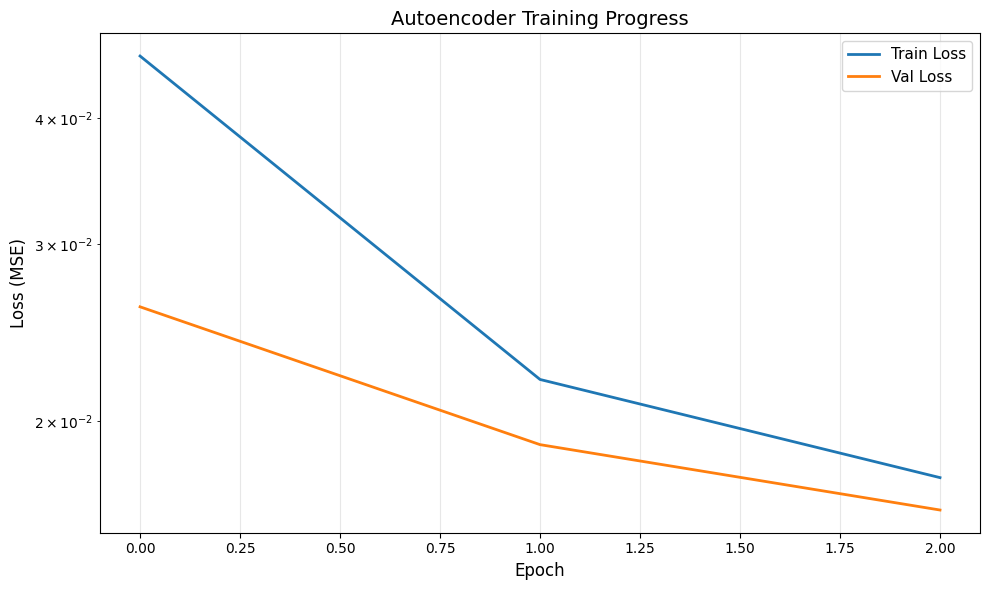


Test MSE: 0.016028

Visualizing reconstructions...


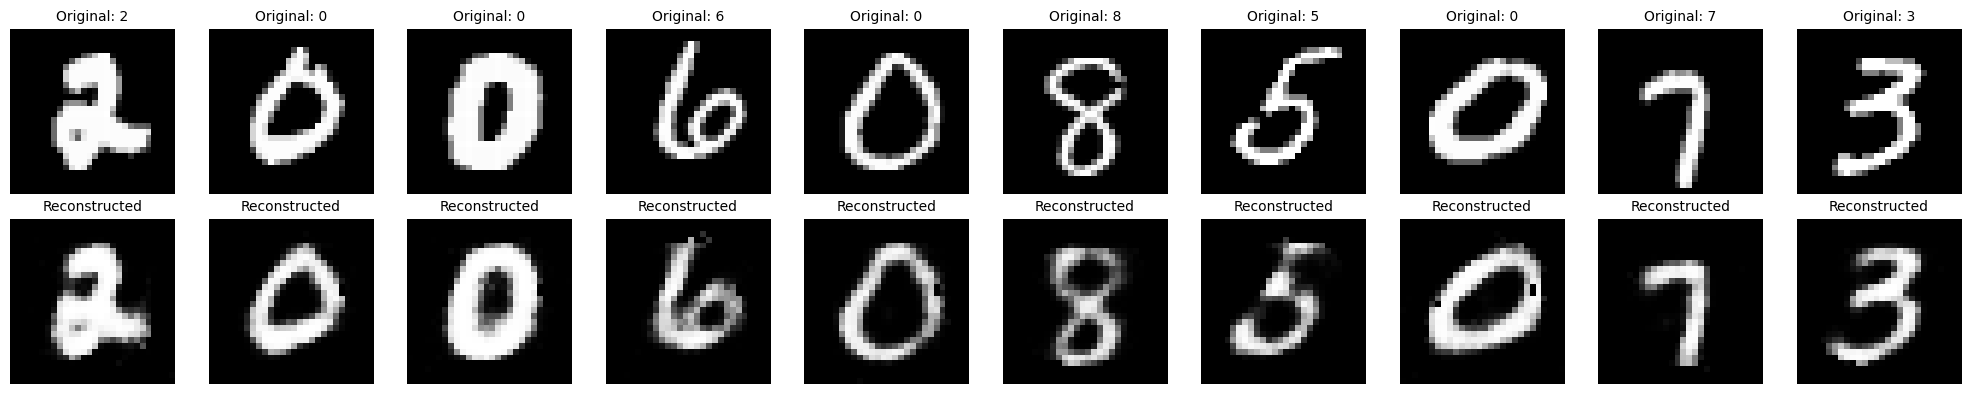


Visualizing reconstructions by digit...


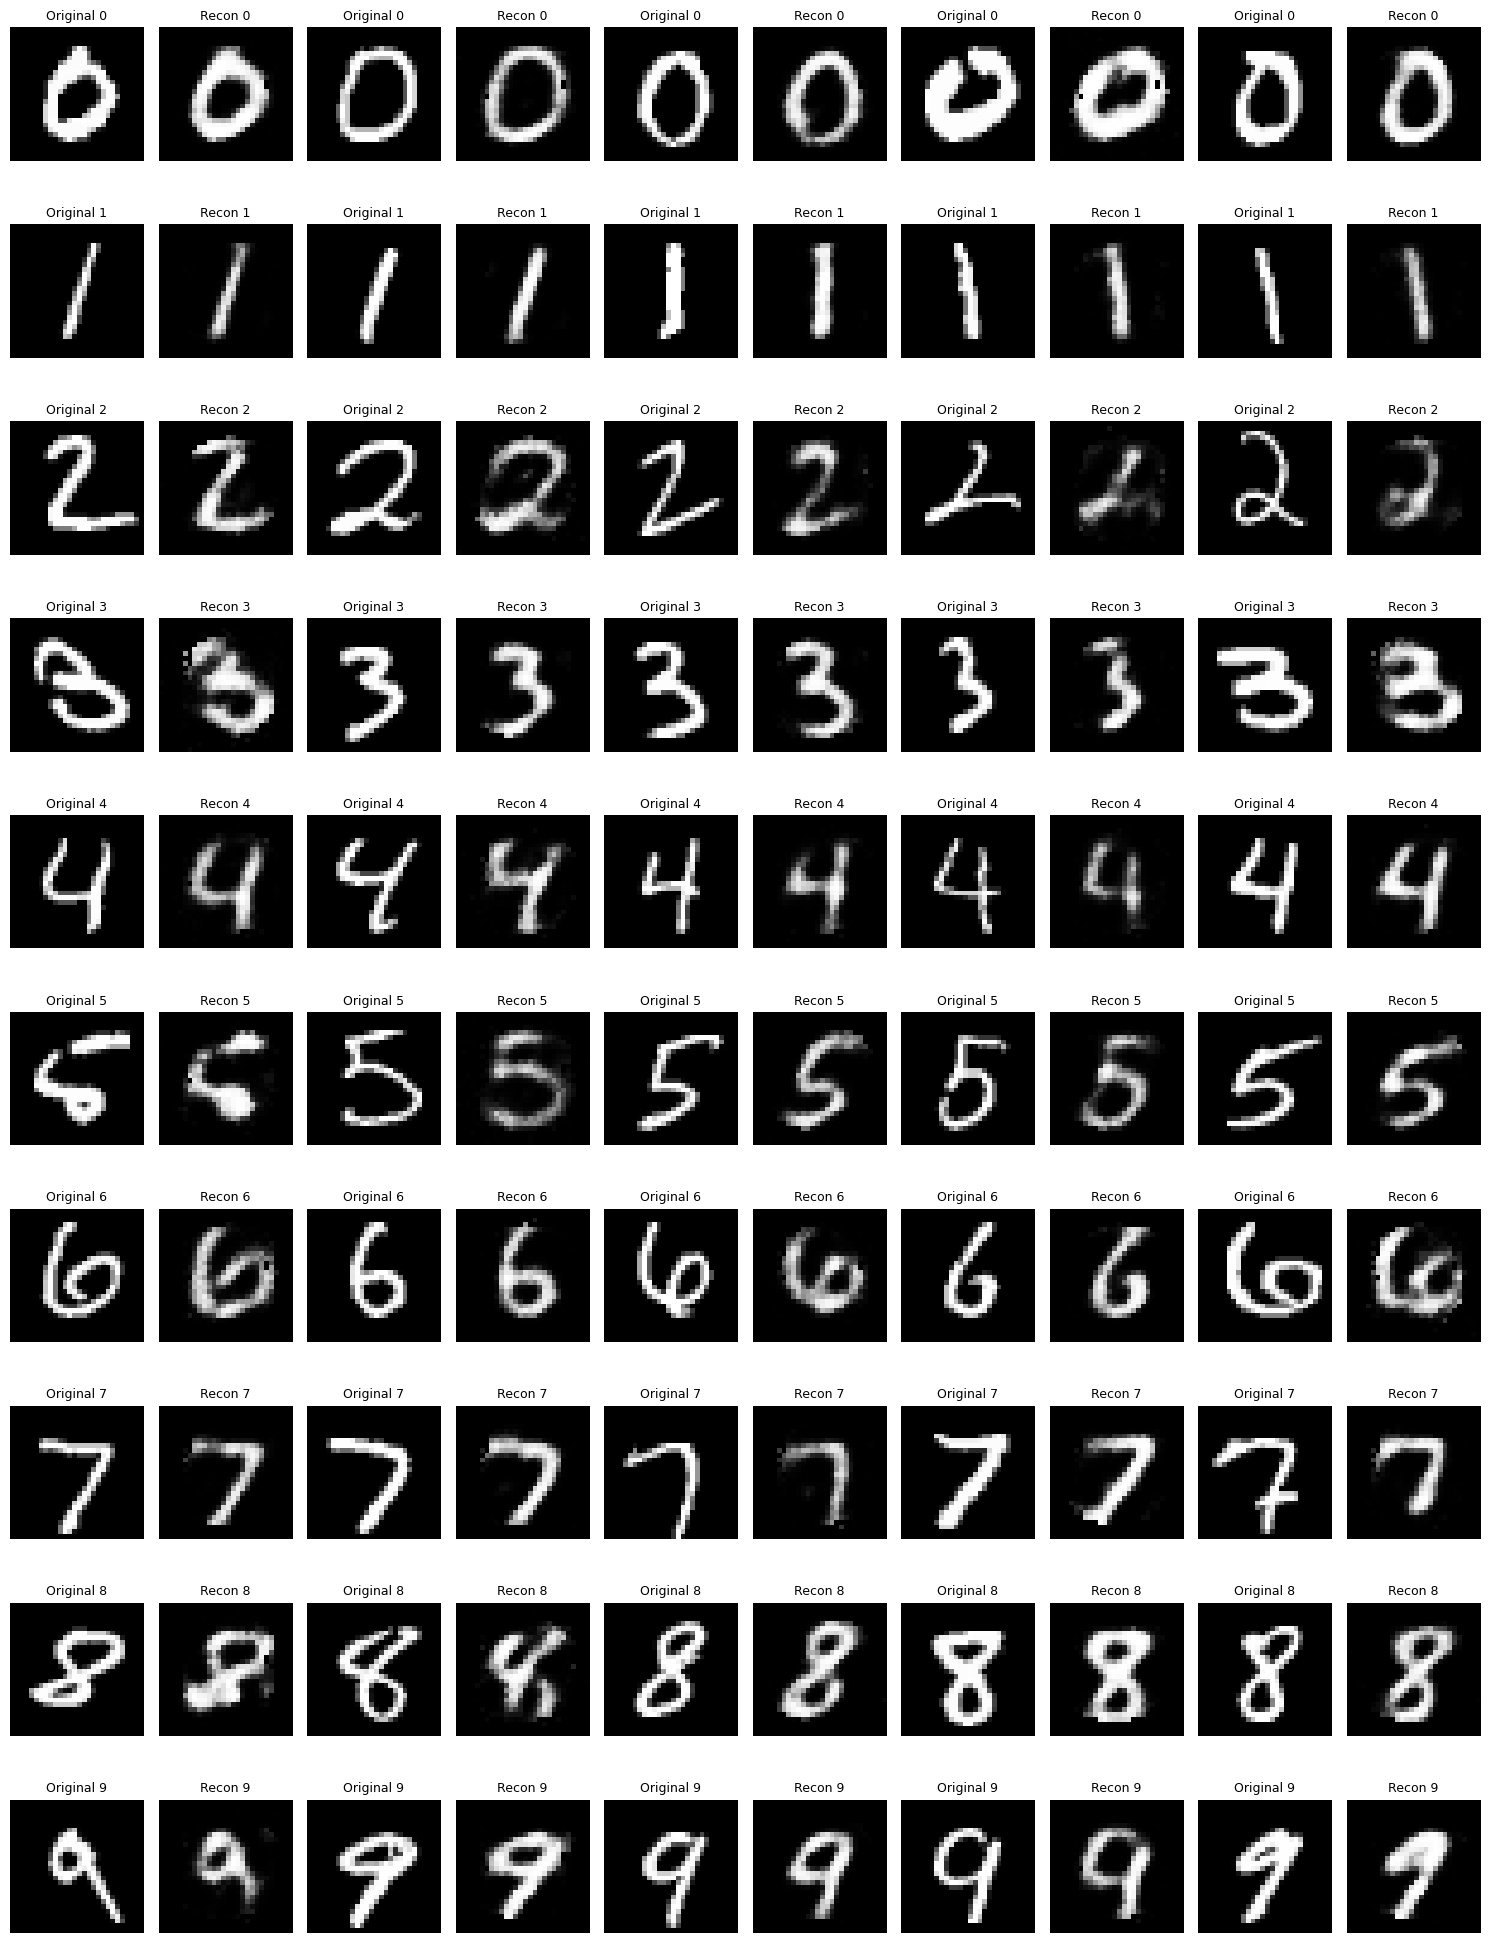


Analyzing latent space...


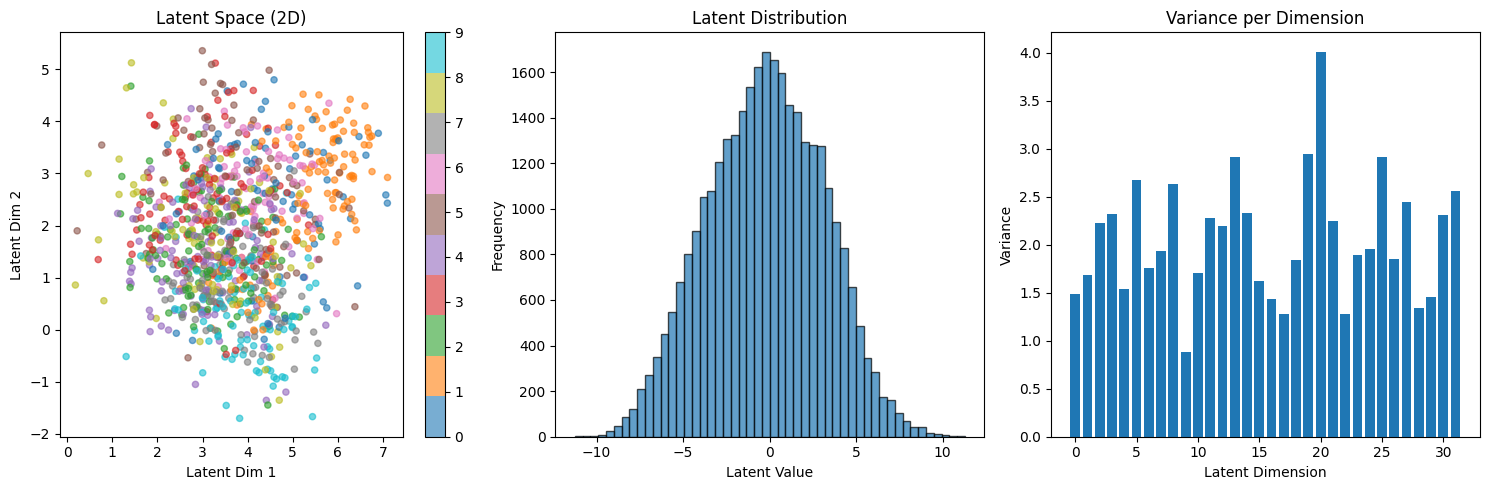

Latent statistics:
  Shape: (1000, 32)
  Mean: -0.2406, Std: 3.3533
  Min: -11.2605, Max: 11.2896


In [5]:
class AutoencoderTrainer:
    """Trainer for MLP Autoencoder"""
    
    def __init__(self, autoencoder: MLPAutoencoder, batch_size: int = 128):
        self.autoencoder = autoencoder
        self.batch_size = batch_size
        self.train_losses = []
        self.val_losses = []
    
    def train_epoch(self, train_images: np.ndarray, epoch: int = 0):
        # Shuffle data each epoch
        indices = np.random.permutation(len(train_images))
        train_images_shuffled = train_images[indices]
        
        num_batches = len(train_images_shuffled) // self.batch_size
        total_loss = 0.0
        
        for batch_idx in range(num_batches):
            start_idx = batch_idx * self.batch_size
            end_idx = start_idx + self.batch_size
            batch = train_images_shuffled[start_idx:end_idx]
            
            loss, _, _ = self.autoencoder.train_step(batch)
            self.autoencoder.update(clip_value=10.0)
            total_loss += float(loss)
            
            # Progress every 100 batches
            if (batch_idx + 1) % 100 == 0:
                print(f"  Batch {batch_idx+1}/{num_batches}, Loss: {loss:.6f}")
        
        return total_loss / num_batches
    
    def validate(self, val_images: np.ndarray):
        num_batches = len(val_images) // self.batch_size
        total_loss = 0.0
        
        for batch_idx in range(num_batches):
            start_idx = batch_idx * self.batch_size
            end_idx = start_idx + self.batch_size
            batch = val_images[start_idx:end_idx]
            
            x_recon = self.autoencoder.predict(batch)
            loss = np.mean((batch - x_recon) ** 2)
            total_loss += float(loss)
        
        return total_loss / num_batches
    
    def train(self, train_images: np.ndarray, val_images: np.ndarray = None, 
              epochs: int = 20, early_stopping_patience: int = 5):
        print(f"\nTraining for {epochs} epochs (batch_size={self.batch_size}, lr={self.autoencoder.lr})")
        print("=" * 60)
        
        best_val_loss = float('inf')
        patience_counter = 0
        
        for epoch in range(epochs):
            print(f"\nEpoch {epoch+1}/{epochs}")
            
            # Train
            train_loss = self.train_epoch(train_images, epoch)
            self.train_losses.append(train_loss)
            
            # Validate
            if val_images is not None:
                val_loss = self.validate(val_images)
                self.val_losses.append(val_loss)
                print(f"Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
                
                # Early stopping
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    patience_counter = 0
                else:
                    patience_counter += 1
                    if patience_counter >= early_stopping_patience:
                        print(f"\nEarly stopping at epoch {epoch+1}")
                        break
            else:
                print(f"Train Loss: {train_loss:.6f}")
        
        print("\nTraining completed!")
        return self.train_losses, self.val_losses
    
    def evaluate(self, test_images: np.ndarray, num_samples: int = 1000):
        test_subset = test_images[:num_samples]
        reconstructions = self.autoencoder.predict(test_subset)
        mse = np.mean((test_subset - reconstructions) ** 2)
        print(f"\nTest MSE: {mse:.6f}")
        return mse, reconstructions


def visualize_reconstructions(autoencoder: MLPAutoencoder, test_images: np.ndarray, 
                              test_labels: np.ndarray, num_samples: int = 10):
    """Visualize original vs reconstructed images"""
    print("\nVisualizing reconstructions...")
    
    indices = np.random.choice(len(test_images), num_samples, replace=False)
    samples = test_images[indices]
    labels = test_labels[indices]
    
    reconstructions = autoencoder.predict(samples)
    
    fig, axes = plt.subplots(2, num_samples, figsize=(20, 4))
    
    for i in range(num_samples):
        # Original
        axes[0, i].imshow(samples[i].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
        axes[0, i].set_title(f'Original: {labels[i]}', fontsize=10)
        axes[0, i].axis('off')
        
        # Reconstructed
        axes[1, i].imshow(reconstructions[i].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
        axes[1, i].set_title('Reconstructed', fontsize=10)
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()


def visualize_by_digit(autoencoder: MLPAutoencoder, test_images: np.ndarray, 
                       test_labels: np.ndarray, num_per_digit: int = 5):
    """Visualize reconstructions for each digit (0-9)"""
    print("\nVisualizing reconstructions by digit...")
    
    fig, axes = plt.subplots(10, num_per_digit * 2, figsize=(15, 20))
    
    for digit in range(10):
        digit_indices = np.where(test_labels == digit)[0]
        selected = digit_indices[:num_per_digit]
        
        samples = test_images[selected]
        reconstructions = autoencoder.predict(samples)
        
        for i in range(num_per_digit):
            # Original
            axes[digit, i * 2].imshow(samples[i].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
            axes[digit, i * 2].set_title(f'Original {digit}', fontsize=9)
            axes[digit, i * 2].axis('off')
            
            # Reconstructed
            axes[digit, i * 2 + 1].imshow(reconstructions[i].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
            axes[digit, i * 2 + 1].set_title(f'Recon {digit}', fontsize=9)
            axes[digit, i * 2 + 1].axis('off')
    
    plt.tight_layout()
    plt.show()


def plot_training_curves(train_losses: list, val_losses: list = None):
    """Plot training and validation curves"""
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss', linewidth=2)
    if val_losses:
        plt.plot(val_losses, label='Val Loss', linewidth=2)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss (MSE)', fontsize=12)
    plt.title('Autoencoder Training Progress', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    plt.tight_layout()
    plt.show()


def analyze_latent_space(autoencoder: MLPAutoencoder, test_images: np.ndarray, 
                         test_labels: np.ndarray, num_samples: int = 1000):
    """Analyze latent space"""
    print("\nAnalyzing latent space...")
    
    samples = test_images[:num_samples]
    labels = test_labels[:num_samples]
    latent = autoencoder.encode(samples)
    
    fig = plt.figure(figsize=(15, 5))
    
    # 2D projection
    ax1 = fig.add_subplot(131)
    scatter = ax1.scatter(latent[:, 0], latent[:, 1], c=labels, cmap='tab10', alpha=0.6, s=20)
    ax1.set_xlabel('Latent Dim 1')
    ax1.set_ylabel('Latent Dim 2')
    ax1.set_title('Latent Space (2D)')
    plt.colorbar(scatter, ax=ax1)
    
    # Distribution
    ax2 = fig.add_subplot(132)
    ax2.hist(latent.flatten(), bins=50, alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Latent Value')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Latent Distribution')
    
    # Per-dimension variance
    ax3 = fig.add_subplot(133)
    variances = np.var(latent, axis=0)
    ax3.bar(range(len(variances)), variances)
    ax3.set_xlabel('Latent Dimension')
    ax3.set_ylabel('Variance')
    ax3.set_title('Variance per Dimension')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Latent statistics:")
    print(f"  Shape: {latent.shape}")
    print(f"  Mean: {latent.mean():.4f}, Std: {latent.std():.4f}")
    print(f"  Min: {latent.min():.4f}, Max: {latent.max():.4f}")


def run_complete_experiment():
    """Run complete autoencoder experiment"""
    print("=" * 60)
    print("MNIST AUTOENCODER EXPERIMENT")
    print("=" * 60)
    
    # Load data (already normalized!)
    loader = MNISTLoader()
    train_imgs, train_lbls, val_imgs, val_lbls, test_imgs, test_lbls = loader.load_mnist()
    
    # Create autoencoder
    autoencoder = MLPAutoencoder(
        input_dim=784,
        latent_dim=32,
        encoder_hidden_dims=[512, 256, 128],  # NO latent_dim here!
        decoder_hidden_dims=[128, 256, 512],
        activation_class=ReLU,
        lr=0.001  # Better learning rate
    )
    
    # Train
    trainer = AutoencoderTrainer(autoencoder, batch_size=128)
    train_losses, val_losses = trainer.train(train_imgs, val_imgs, epochs=3, early_stopping_patience=5)
    
    # Plot curves
    plot_training_curves(train_losses, val_losses)
    
    # Evaluate
    test_mse, _ = trainer.evaluate(test_imgs)
    
    # Visualize
    visualize_reconstructions(autoencoder, test_imgs, test_lbls, num_samples=10)
    visualize_by_digit(autoencoder, test_imgs, test_lbls, num_per_digit=5)
    
    # Analyze latent space
    analyze_latent_space(autoencoder, test_imgs, test_lbls)
    
    return autoencoder, train_losses, val_losses

# Run experiment
autoencoder, train_losses, val_losses = run_complete_experiment()

MNIST AUTOENCODER - QUICK TEST
Loading MNIST dataset...
Dataset loaded:
  Train: (54000, 784), Val: (6000, 784), Test: (10000, 784)
Autoencoder Architecture:
  Encoder: 784 -> 256 -> 128 -> 32
  Decoder: 32 -> 128 -> 256 -> 784
  Total parameters: 476,720

Training for 3 epochs...

Epoch 1/3
Train Loss: 0.195646

Epoch 2/3
Train Loss: 0.078045

Epoch 3/3
Train Loss: 0.067733

Visualizing results...

Visualizing reconstructions...


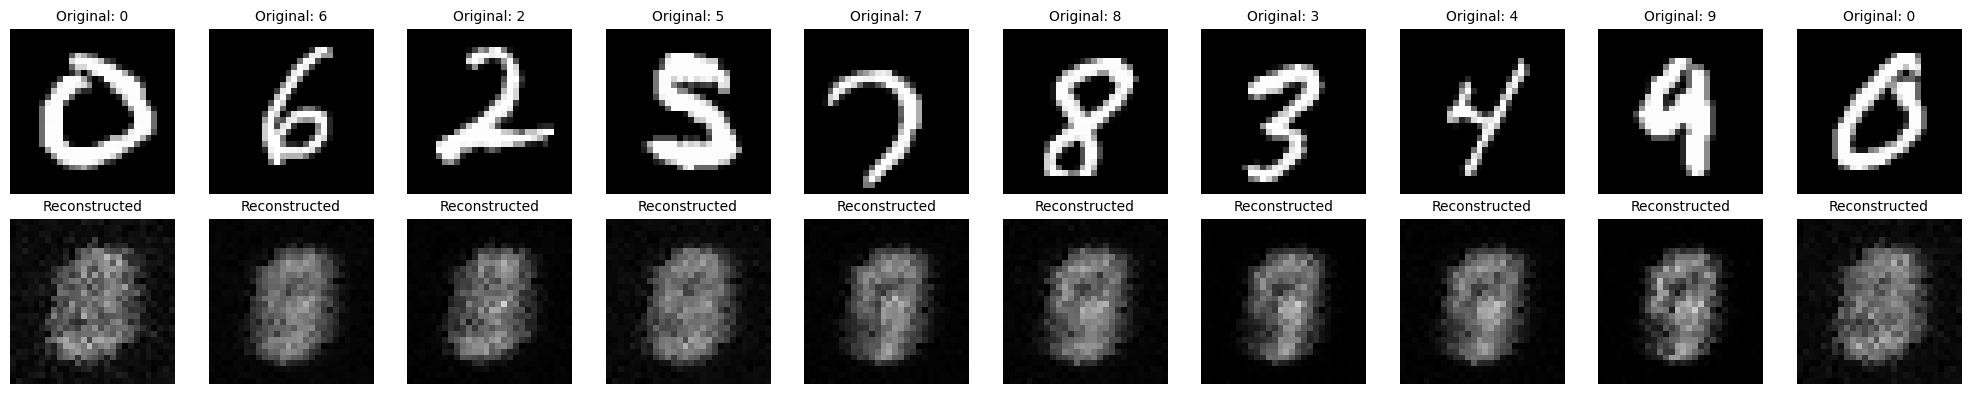

In [6]:
# Quick test with smaller network and fewer epochs
print("=" * 60)
print("MNIST AUTOENCODER - QUICK TEST")
print("=" * 60)

# Load data
loader = MNISTLoader()
train_imgs, train_lbls, val_imgs, val_lbls, test_imgs, test_lbls = loader.load_mnist()

# Create smaller autoencoder for testing
autoencoder_test = MLPAutoencoder(
    input_dim=784,
    latent_dim=32,
    encoder_hidden_dims=[256, 128],
    decoder_hidden_dims=[128, 256],
    activation_class=ReLU,
    lr=0.001
)

# Train for just 3 epochs
trainer_test = AutoencoderTrainer(autoencoder_test, batch_size=256)

print("\nTraining for 3 epochs...")
for epoch in range(3):
    print(f"\nEpoch {epoch+1}/3")
    train_loss = trainer_test.train_epoch(train_imgs[:5000], epoch)  # Use subset
    print(f"Train Loss: {train_loss:.6f}")

# Visualize
print("\nVisualizing results...")
visualize_reconstructions(autoencoder_test, test_imgs, test_lbls, num_samples=10)

Testing LFW dataset loading...
Loading LFW dataset...
LFW dataset loaded:
  Total images: 13233
  Image shape: (13233, 4096)
  Normal class (George_W_Bush): 530 images
  Anomalous classes: 12703 images

Top 10 persons by image count:
  George_W_Bush: 530 images
  Colin_Powell: 236 images
  Tony_Blair: 144 images
  Donald_Rumsfeld: 121 images
  Gerhard_Schroeder: 109 images
  Ariel_Sharon: 77 images
  Hugo_Chavez: 71 images
  Junichiro_Koizumi: 60 images
  Jean_Chretien: 55 images
  John_Ashcroft: 53 images
LFW dataset loaded:
  Total images: 13233
  Image shape: (13233, 4096)
  Normal class (George_W_Bush): 530 images
  Anomalous classes: 12703 images

Top 10 persons by image count:
  George_W_Bush: 530 images
  Colin_Powell: 236 images
  Tony_Blair: 144 images
  Donald_Rumsfeld: 121 images
  Gerhard_Schroeder: 109 images
  Ariel_Sharon: 77 images
  Hugo_Chavez: 71 images
  Junichiro_Koizumi: 60 images
  Jean_Chretien: 55 images
  John_Ashcroft: 53 images


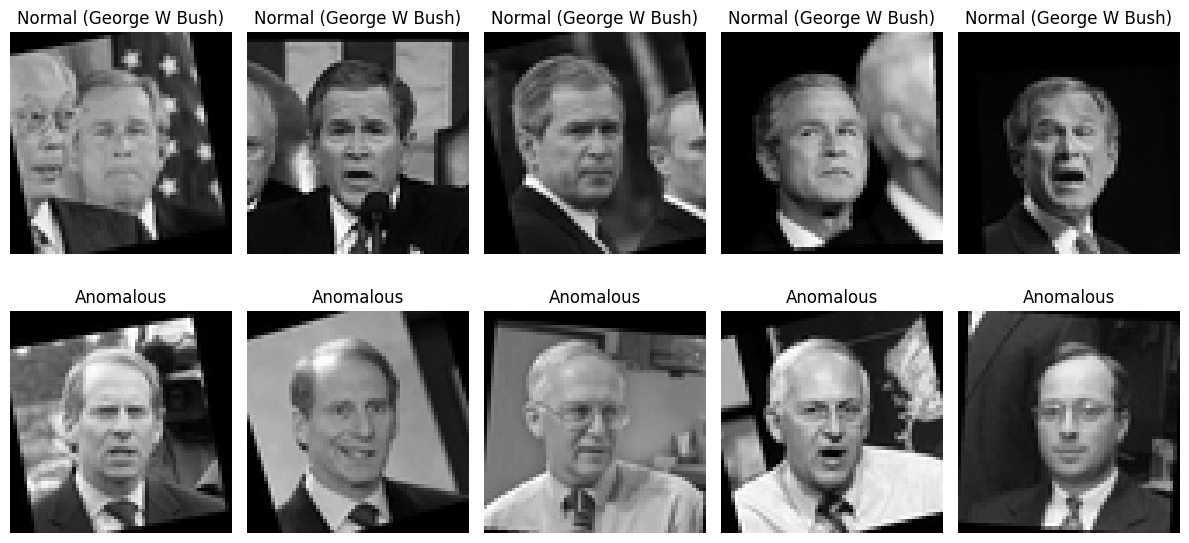

In [7]:
# LFW Dataset Loading and Preprocessing for Anomaly Detection
import os
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, roc_curve
import shutil

class LFWLoader:
    """
    Loader for Labeled Faces in the Wild (LFW) dataset
    """
    def __init__(self, lfw_dir: str = "/home/karthik/assignment-3-karthikvmala-main/dataset/Q3/LFW_Dataset"):
        self.lfw_dir = lfw_dir
        self.normal_class = "George_W_Bush"  # Normal class for anomaly detection
        
    def load_lfw_data(self):
        """Load and preprocess LFW dataset"""
        print("Loading LFW dataset...")
        
        # Collect all images with their labels
        all_images = []
        all_labels = []  # 0 for normal (George_W_Bush), 1 for anomalous (others)
        person_counts = {}
        
        if not os.path.exists(self.lfw_dir):
            print(f"LFW directory not found: {self.lfw_dir}")
            return None, None, None
        
        # Walk through the directory structure
        for person_name in os.listdir(self.lfw_dir):
            person_path = os.path.join(self.lfw_dir, person_name)
            
            if not os.path.isdir(person_path):
                continue
            
            # Count images for this person
            image_files = [f for f in os.listdir(person_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            person_counts[person_name] = len(image_files)
            
            # Process each image
            for image_file in image_files:
                image_path = os.path.join(person_path, image_file)
                
                try:
                    # Load and preprocess image
                    img = Image.open(image_path).convert('L')  # Convert to grayscale
                    img = img.resize((64, 64), Image.Resampling.LANCZOS)  # Resize to 64x64
                    img_array = np.array(img, dtype=np.float32) / 255.0  # Normalize to [0,1]
                    
                    # Flatten to 1D
                    img_flat = img_array.flatten()
                    
                    all_images.append(img_flat)
                    
                    # Label: 0 for normal (George_W_Bush), 1 for anomalous
                    if person_name == self.normal_class:
                        all_labels.append(0)  # Normal
                    else:
                        all_labels.append(1)  # Anomalous
                        
                except Exception as e:
                    print(f"Error loading {image_path}: {e}")
                    continue
        
        if not all_images:
            print("No images found in LFW dataset!")
            return None, None, None
        
        # Convert to numpy arrays
        images = np.array(all_images, dtype=np.float32)
        labels = np.array(all_labels, dtype=np.int32)
        
        print(f"LFW dataset loaded:")
        print(f"  Total images: {len(images)}")
        print(f"  Image shape: {images.shape}")
        print(f"  Normal class ({self.normal_class}): {np.sum(labels == 0)} images")
        print(f"  Anomalous classes: {np.sum(labels == 1)} images")
        
        # Print person counts (top 10)
        sorted_persons = sorted(person_counts.items(), key=lambda x: x[1], reverse=True)
        print(f"\nTop 10 persons by image count:")
        for person, count in sorted_persons[:10]:
            print(f"  {person}: {count} images")
        
        return images, labels, person_counts
    
    def split_data(self, images, labels, test_ratio=0.2):
        """Split data into train and test sets"""
        # Separate normal and anomalous data
        normal_mask = labels == 0
        anomalous_mask = labels == 1
        
        normal_images = images[normal_mask]
        anomalous_images = images[anomalous_mask]
        
        # Split normal data (for training autoencoder)
        n_normal = len(normal_images)
        n_normal_train = int(n_normal * (1 - test_ratio))
        
        normal_train = normal_images[:n_normal_train]
        normal_test = normal_images[n_normal_train:]
        
        # Use all anomalous data for testing
        anomalous_test = anomalous_images
        
        # Combine test data
        test_images = np.concatenate([normal_test, anomalous_test], axis=0)
        test_labels = np.concatenate([
            np.zeros(len(normal_test), dtype=np.int32),  # Normal
            np.ones(len(anomalous_test), dtype=np.int32)  # Anomalous
        ])
        
        print(f"Data split:")
        print(f"  Train (normal only): {len(normal_train)} images")
        print(f"  Test normal: {len(normal_test)} images")
        print(f"  Test anomalous: {len(anomalous_test)} images")
        print(f"  Test total: {len(test_images)} images")
        
        return normal_train, test_images, test_labels

# Test LFW loading
def test_lfw_loading():
    """Test LFW dataset loading"""
    print("Testing LFW dataset loading...")
    lfw_loader = LFWLoader()
    
    images, labels, person_counts = lfw_loader.load_lfw_data()
    
    if images is not None:
        # Visualize some samples
        fig, axes = plt.subplots(2, 5, figsize=(12, 6))
        
        # Show normal samples (George W Bush)
        normal_indices = np.where(labels == 0)[0]
        for i in range(min(5, len(normal_indices))):
            img = images[normal_indices[i]].reshape(64, 64)
            axes[0, i].imshow(img, cmap='gray')
            axes[0, i].set_title('Normal (George W Bush)')
            axes[0, i].axis('off')
        
        # Show anomalous samples
        anomalous_indices = np.where(labels == 1)[0]
        for i in range(min(5, len(anomalous_indices))):
            img = images[anomalous_indices[i]].reshape(64, 64)
            axes[1, i].imshow(img, cmap='gray')
            axes[1, i].set_title('Anomalous')
            axes[1, i].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        return images, labels, person_counts
    else:
        return None, None, None

# Test LFW loading
lfw_images, lfw_labels, person_counts = test_lfw_loading()

def train_autoencoder_on_mnist():
    """Complete autoencoder training and evaluation on MNIST"""
    print("Starting Autoencoder Training on MNIST")
    print("=" * 50)
    
    # Normalize input data to [0, 1]
    train_images_normalized = train_images.astype(_np.float32) / 255.0
    test_images_normalized = test_images.astype(_np.float32) / 255.0
    
    # Create autoencoder
    input_dim = 784  # 28x28 MNIST images
    latent_dim = 32  # Compressed representation
    autoencoder = MLPAutoencoder(
        input_dim=input_dim,
        latent_dim=latent_dim,
        encoder_hidden_dims=[512, 256, latent_dim],
        decoder_hidden_dims=[latent_dim, 256, 512],
        activation_class=ReLU,
        lr=1e-3
    )
    
    # Create trainer
    trainer = AutoencoderTrainer(autoencoder, batch_size=128)
    
    # Train autoencoder with normalized data
    print("\nTraining autoencoder...")
    train_losses = trainer.train(train_images_normalized.reshape(-1, 784), epochs=2)
    
    # Evaluate with normalized data
    print("\nEvaluating autoencoder...")
    test_mse, test_reconstructions = trainer.evaluate(test_images_normalized.reshape(-1, 784), num_samples=1000)
    
    return autoencoder, train_losses, test_reconstructions


In [ ]:
# Anomaly Detection with Autoencoder
class AnomalyDetector:
    """
    Anomaly detection using autoencoder on LFW dataset
    """
    def __init__(self, input_dim: int = 4096, latent_dim: int = 64, lr: float = 1e-3):
        """
        Args:
            input_dim: Input image dimension (64x64 = 4096 for LFW)
            latent_dim: Latent representation dimension
            lr: Learning rate
        """
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.lr = lr
        
        # Create autoencoder
        self.autoencoder = MLPAutoencoder(
            input_dim=input_dim,
            latent_dim=latent_dim,
            encoder_hidden_dims=[2048, 1024, 256],
            decoder_hidden_dims=[256, 1024, 2048],
            activation_class=ReLU,
            lr=lr
        )
        
        self.threshold = None  # Will be determined during evaluation
    
    def train_on_normal_data(self, normal_images: _np.ndarray, epochs: int = 100, batch_size: int = 64):
        """Train autoencoder exclusively on normal data (George W Bush)"""
        print(f"Training autoencoder on normal data...")
        print(f"  Normal images: {len(normal_images)}")
        print(f"  Epochs: {epochs}")
        print(f"  Batch size: {batch_size}")
        
        train_losses = []
        
        for epoch in range(epochs):
            # Shuffle data
            indices = _np.random.permutation(len(normal_images))
            epoch_loss = 0.0
            num_batches = 0
            
            for i in range(0, len(normal_images), batch_size):
                # Get batch
                end_idx = min(i + batch_size, len(normal_images))
                batch_indices = indices[i:end_idx]
                batch_images = normal_images[batch_indices]
                
                # Training step
                loss, _, _ = self.autoencoder.train_step(batch_images)
                self.autoencoder.update()
                
                epoch_loss += float(loss)
                num_batches += 1
            
            avg_loss = epoch_loss / num_batches
            train_losses.append(avg_loss)
            
            if (epoch + 1) % 20 == 0:
                print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.6f}")
        
        print("Training completed!")
        return train_losses
    
    def compute_reconstruction_errors(self, images: _np.ndarray) -> _np.ndarray:
        """Compute reconstruction errors for given images"""
        batch_size = 128
        reconstruction_errors = []
        
        for i in range(0, len(images), batch_size):
            end_idx = min(i + batch_size, len(images))
            batch_images = images[i:end_idx]
            
            # Get reconstructions
            reconstructions = self.autoencoder.predict(batch_images)
            
            # Compute MSE for each image
            mse_errors = _np.mean((batch_images - reconstructions) ** 2, axis=1)
            reconstruction_errors.extend(mse_errors)
        
        return _np.array(reconstruction_errors)
    
    def determine_threshold(self, normal_errors: _np.ndarray, method: str = "percentile", percentile: float = 95.0):
        """Determine threshold for anomaly detection"""
        if method == "percentile":
            self.threshold = _np.percentile(normal_errors, percentile)
        elif method == "mean_std":
            # Threshold = mean + 2*std
            self.threshold = _np.mean(normal_errors) + 2 * _np.std(normal_errors)
        else:
            raise ValueError(f"Unknown threshold method: {method}")
        
        print(f"Threshold determined ({method}): {self.threshold:.6f}")
        return self.threshold
    
    def predict_anomalies(self, reconstruction_errors: _np.ndarray) -> _np.ndarray:
        """Predict anomalies based on reconstruction errors"""
        if self.threshold is None:
            raise ValueError("Threshold not set. Call determine_threshold first.")
        
        # 1 for anomalous (high error), 0 for normal (low error)
        predictions = (reconstruction_errors > self.threshold).astype(_np.int32)
        return predictions
    
    def evaluate(self, test_images: _np.ndarray, test_labels: _np.ndarray) -> dict:
        """Evaluate anomaly detection performance"""
        print("Evaluating anomaly detection...")
        
        # Compute reconstruction errors for all test images
        reconstruction_errors = self.compute_reconstruction_errors(test_images)
        
        # Separate normal and anomalous errors for threshold determination
        normal_mask = test_labels == 0
        anomalous_mask = test_labels == 1
        
        normal_errors = reconstruction_errors[normal_mask]
        anomalous_errors = reconstruction_errors[anomalous_mask]
        
        print(f"Reconstruction errors:")
        print(f"  Normal: mean={_np.mean(normal_errors):.6f}, std={_np.std(normal_errors):.6f}")
        print(f"  Anomalous: mean={_np.mean(anomalous_errors):.6f}, std={_np.std(anomalous_errors):.6f}")
        
        # Determine threshold using normal data
        self.determine_threshold(normal_errors, method="percentile", percentile=95.0)
        
        # Make predictions
        predictions = self.predict_anomalies(reconstruction_errors)
        
        # Calculate metrics
        auc_score = roc_auc_score(test_labels, reconstruction_errors)
        precision, recall, f1, _ = precision_recall_fscore_support(test_labels, predictions, average='binary')
        
        # Calculate additional metrics
        accuracy = _np.mean(predictions == test_labels)
        true_positives = _np.sum((predictions == 1) & (test_labels == 1))
        false_positives = _np.sum((predictions == 1) & (test_labels == 0))
        true_negatives = _np.sum((predictions == 0) & (test_labels == 0))
        false_negatives = _np.sum((predictions == 0) & (test_labels == 1))
        
        results = {
            'auc_score': auc_score,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'accuracy': accuracy,
            'threshold': self.threshold,
            'reconstruction_errors': reconstruction_errors,
            'predictions': predictions,
            'normal_errors': normal_errors,
            'anomalous_errors': anomalous_errors,
            'true_positives': true_positives,
            'false_positives': false_positives,
            'true_negatives': true_negatives,
            'false_negatives': false_negatives
        }
        
        print(f"\nAnomaly Detection Results:")
        print(f"  AUC Score: {auc_score:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall: {recall:.4f}")
        print(f"  F1-Score: {f1:.4f}")
        print(f"  Accuracy: {accuracy:.4f}")
        print(f"  Threshold: {self.threshold:.6f}")
        
        return results
    
    def visualize_results(self, test_images: _np.ndarray, test_labels: _np.ndarray, results: dict, num_samples: int = 10):
        """Visualize anomaly detection results"""
        reconstruction_errors = results['reconstruction_errors']
        predictions = results['predictions']
        
        # Find examples of true/false positives and true/false negatives
        true_positives = _np.where((predictions == 1) & (test_labels == 1))[0]
        false_positives = _np.where((predictions == 1) & (test_labels == 0))[0]
        true_negatives = _np.where((predictions == 0) & (test_labels == 0))[0]
        false_negatives = _np.where((predictions == 0) & (test_labels == 1))[0]
        
        print(f"Classification results:")
        print(f"  True Positives: {len(true_positives)}")
        print(f"  False Positives: {len(false_positives)}")
        print(f"  True Negatives: {len(true_negatives)}")
        print(f"  False Negatives: {len(false_negatives)}")
        
        # Create visualization
        fig, axes = plt.subplots(4, min(num_samples, 10), figsize=(15, 12))
        if axes.ndim == 1:
            axes = axes.reshape(-1, 1)
        
        # True Positives (correctly detected anomalies)
        for i in range(min(num_samples, len(true_positives))):
            idx = true_positives[i]
            img = test_images[idx].reshape(64, 64)
            axes[0, i].imshow(img, cmap='gray')
            axes[0, i].set_title(f'TP (Error: {reconstruction_errors[idx]:.4f})')
            axes[0, i].axis('off')
        
        # False Positives (normal detected as anomalous)
        for i in range(min(num_samples, len(false_positives))):
            idx = false_positives[i]
            img = test_images[idx].reshape(64, 64)
            axes[1, i].imshow(img, cmap='gray')
            axes[1, i].set_title(f'FP (Error: {reconstruction_errors[idx]:.4f})')
            axes[1, i].axis('off')
        
        # True Negatives (correctly detected normal)
        for i in range(min(num_samples, len(true_negatives))):
            idx = true_negatives[i]
            img = test_images[idx].reshape(64, 64)
            axes[2, i].imshow(img, cmap='gray')
            axes[2, i].set_title(f'TN (Error: {reconstruction_errors[idx]:.4f})')
            axes[2, i].axis('off')
        
        # False Negatives (anomalous detected as normal)
        for i in range(min(num_samples, len(false_negatives))):
            idx = false_negatives[i]
            img = test_images[idx].reshape(64, 64)
            axes[3, i].imshow(img, cmap='gray')
            axes[3, i].set_title(f'FN (Error: {reconstruction_errors[idx]:.4f})')
            axes[3, i].axis('off')
        
        # Add row labels
        row_labels = ['True Positives', 'False Positives', 'True Negatives', 'False Negatives']
        for i, label in enumerate(row_labels):
            axes[i, 0].text(-0.5, 0.5, label, transform=axes[i, 0].transAxes, 
                           rotation=90, va='center', ha='right', fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        # Plot ROC curve
        fpr, tpr, _ = roc_curve(test_labels, reconstruction_errors)
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {results["auc_score"]:.4f})')
        plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve for Anomaly Detection')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        
        # Plot reconstruction error distributions
        plt.figure(figsize=(10, 6))
        plt.hist(results['normal_errors'], bins=50, alpha=0.7, label='Normal (George W Bush)', density=True)
        plt.hist(results['anomalous_errors'], bins=50, alpha=0.7, label='Anomalous (Others)', density=True)
        plt.axvline(results['threshold'], color='red', linestyle='--', label=f'Threshold = {results["threshold"]:.4f}')
        plt.xlabel('Reconstruction Error (MSE)')
        plt.ylabel('Density')
        plt.title('Distribution of Reconstruction Errors')
        plt.legend()
        plt.yscale('log')
        plt.show()

# Run complete anomaly detection experiment
def run_anomaly_detection_experiment():
    """Run complete anomaly detection experiment"""
    print("Starting Anomaly Detection Experiment")
    print("=" * 50)
    
    # Load and split LFW data
    lfw_loader = LFWLoader()
    images, labels, person_counts = lfw_loader.load_lfw_data()
    
    if images is None:
        print("Failed to load LFW data!")
        return None
    
    # Split data
    normal_train, test_images, test_labels = lfw_loader.split_data(images, labels, test_ratio=0.2)
    
    # Create and train anomaly detector
    detector = AnomalyDetector(input_dim=4096, latent_dim=64, lr=1e-3)
    
    # Train on normal data only
    train_losses = detector.train_on_normal_data(normal_train, epochs=100, batch_size=64)
    
    # Evaluate on test data
    results = detector.evaluate(test_images, test_labels)
    
    # Visualize results
    detector.visualize_results(test_images, test_labels, results, num_samples=8)
    
    return detector, results, train_losses

# Run the experiment
anomaly_detector, anomaly_results, anomaly_train_losses = run_anomaly_detection_experiment()


Starting Anomaly Detection Experiment
Loading LFW dataset...


LFW dataset loaded:
  Total images: 13233
  Image shape: (13233, 4096)
  Normal class (George_W_Bush): 530 images
  Anomalous classes: 12703 images

Top 10 persons by image count:
  George_W_Bush: 530 images
  Colin_Powell: 236 images
  Tony_Blair: 144 images
  Donald_Rumsfeld: 121 images
  Gerhard_Schroeder: 109 images
  Ariel_Sharon: 77 images
  Hugo_Chavez: 71 images
  Junichiro_Koizumi: 60 images
  Jean_Chretien: 55 images
  John_Ashcroft: 53 images
Data split:
  Train (normal only): 424 images
  Test normal: 106 images
  Test anomalous: 12703 images
  Test total: 12809 images
Autoencoder Architecture:
  Encoder: 4096 -> 2048 -> 1024 -> 256 -> 64
  Decoder: 64 -> 256 -> 1024 -> 2048 -> 4096
  Total parameters: 21,539,392
Training autoencoder on normal data...
  Normal images: 424
  Epochs: 100
  Batch size: 64
Autoencoder Architecture:
  Encoder: 4096 -> 2048 -> 1024 -> 256 -> 64
  Decoder: 64 -> 256 -> 1024 -> 2048 -> 4096
  Total parameters: 21,539,392
Training autoencoder on nor

Starting Bottleneck Dimension Analysis
Loading LFW dataset...
LFW dataset loaded:
  Total images: 13233
  Image shape: (13233, 4096)
  Normal class (George_W_Bush): 530 images
  Anomalous classes: 12703 images

Top 10 persons by image count:
  George_W_Bush: 530 images
  Colin_Powell: 236 images
  Tony_Blair: 144 images
  Donald_Rumsfeld: 121 images
  Gerhard_Schroeder: 109 images
  Ariel_Sharon: 77 images
  Hugo_Chavez: 71 images
  Junichiro_Koizumi: 60 images
  Jean_Chretien: 55 images
  John_Ashcroft: 53 images
Data split:
  Train (normal only): 424 images
  Test normal: 106 images
  Test anomalous: 12703 images
  Test total: 12809 images
Training autoencoders with different bottleneck dimensions...

Training autoencoder with bottleneck dimension: 16
--------------------------------------------------
Autoencoder Architecture:
  Input: 4096
  Encoder: 4096 -> 2048 -> 1024 -> 256 -> 16
  Decoder: 16 -> 256 -> 1024 -> 2048 -> 4096
  Total parameters: 21514768
Training autoencoder on no

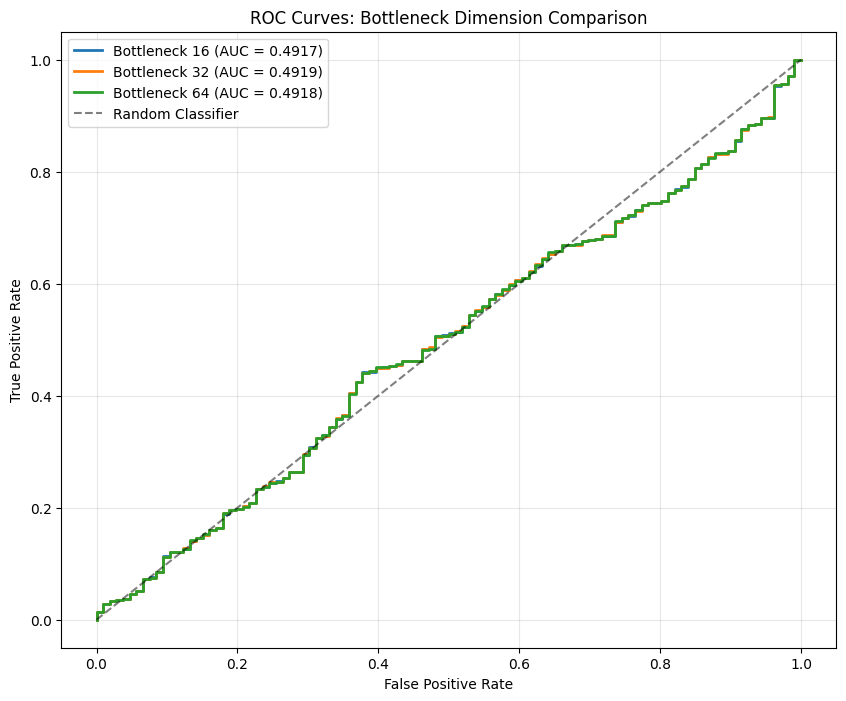

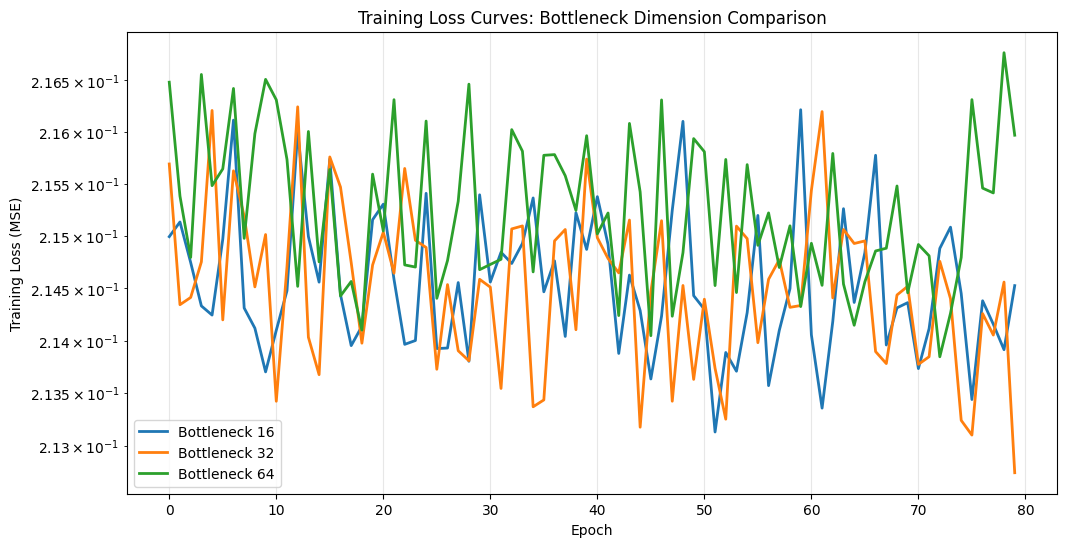

Performance Comparison Across Bottleneck Dimensions:
   Bottleneck     AUC  Precision  Recall  F1-Score  Accuracy
0          16  0.4917     0.9902  0.0476    0.0909    0.0550
1          32  0.4919     0.9902  0.0479    0.0913    0.0553
2          64  0.4918     0.9902  0.0479    0.0913    0.0553


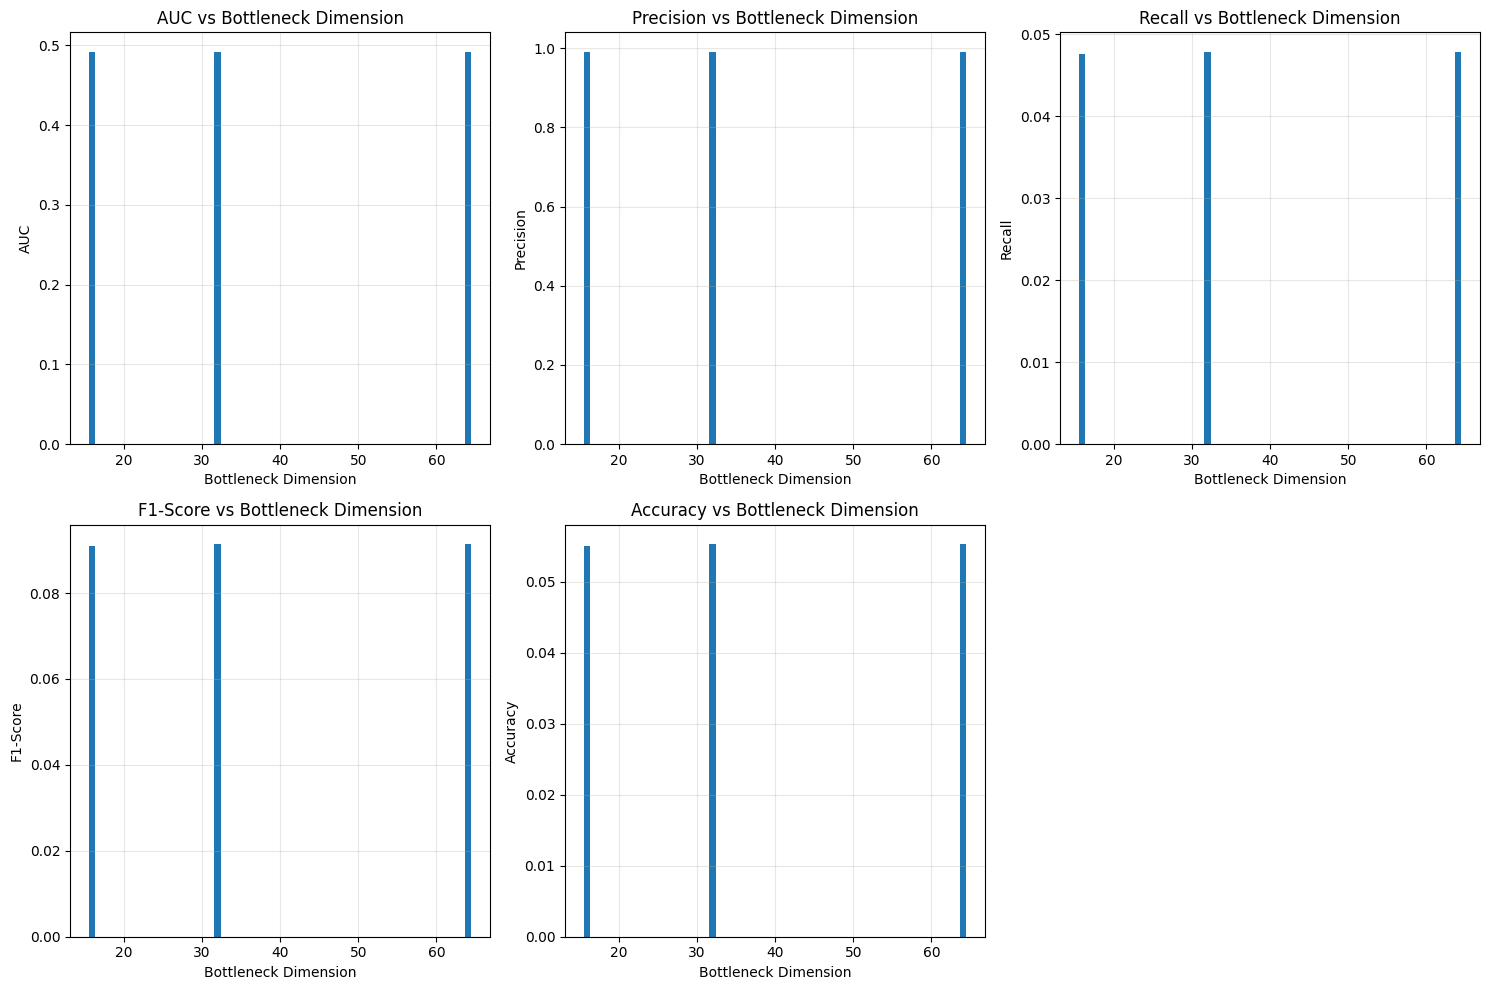


Best model: Bottleneck dimension 32
Best AUC: 0.4919


In [103]:
# Bottleneck Dimension Analysis
from sklearn.metrics import precision_recall_curve, average_precision_score

class BottleneckAnalyzer:
    """
    Analyze the effect of bottleneck dimension on anomaly detection performance
    """
    def __init__(self, input_dim: int = 4096, lr: float = 1e-3):
        self.input_dim = input_dim
        self.lr = lr
        self.results = {}
    
    def train_multiple_bottlenecks(self, normal_train: _np.ndarray, test_images: _np.ndarray, 
                                 test_labels: _np.ndarray, bottleneck_dims: list = [16, 32, 64]):
        """Train autoencoders with different bottleneck dimensions"""
        print("Training autoencoders with different bottleneck dimensions...")
        
        for latent_dim in bottleneck_dims:
            print(f"\nTraining autoencoder with bottleneck dimension: {latent_dim}")
            print("-" * 50)
            
            # Create autoencoder with specific bottleneck dimension
            detector = AnomalyDetector(
                input_dim=self.input_dim,
                latent_dim=latent_dim,
                lr=self.lr
            )
            
            # Train on normal data
            train_losses = detector.train_on_normal_data(normal_train, epochs=80, batch_size=64)
            
            # Evaluate
            results = detector.evaluate(test_images, test_labels)
            
            # Store results
            self.results[latent_dim] = {
                'detector': detector,
                'results': results,
                'train_losses': train_losses
            }
            
            print(f"Completed bottleneck dimension {latent_dim}")
            print(f"  AUC: {results['auc_score']:.4f}")
            print(f"  F1-Score: {results['f1_score']:.4f}")
        
        return self.results
    
    def plot_roc_comparison(self):
        """Plot ROC curves for all bottleneck dimensions"""
        plt.figure(figsize=(10, 8))
        
        for latent_dim, data in self.results.items():
            results = data['results']
            reconstruction_errors = results['reconstruction_errors']
            
            # Get test labels (assuming they're the same for all models)
            test_labels = _np.concatenate([
                _np.zeros(len(results['normal_errors']), dtype=_np.int32),
                _np.ones(len(results['anomalous_errors']), dtype=_np.int32)
            ])
            
            # Compute ROC curve
            fpr, tpr, _ = roc_curve(test_labels, reconstruction_errors)
            auc_score = results['auc_score']
            
            plt.plot(fpr, tpr, linewidth=2, 
                    label=f'Bottleneck {latent_dim} (AUC = {auc_score:.4f})')
        
        plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curves: Bottleneck Dimension Comparison')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
    
    def plot_training_curves_comparison(self):
        """Plot training loss curves for all bottleneck dimensions"""
        plt.figure(figsize=(12, 6))
        
        for latent_dim, data in self.results.items():
            train_losses = data['train_losses']
            plt.plot(train_losses, linewidth=2, label=f'Bottleneck {latent_dim}')
        
        plt.xlabel('Epoch')
        plt.ylabel('Training Loss (MSE)')
        plt.title('Training Loss Curves: Bottleneck Dimension Comparison')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.yscale('log')
        plt.show()
    
    def compare_metrics(self):
        """Compare performance metrics across bottleneck dimensions"""
        metrics_data = []
        
        for latent_dim, data in self.results.items():
            results = data['results']
            metrics_data.append({
                'Bottleneck': latent_dim,
                'AUC': results['auc_score'],
                'Precision': results['precision'],
                'Recall': results['recall'],
                'F1-Score': results['f1_score'],
                'Accuracy': results['accuracy']
            })
        
        # Create comparison table
        import pandas as pd
        df = pd.DataFrame(metrics_data)
        print("Performance Comparison Across Bottleneck Dimensions:")
        print(df.round(4))
        
        # Plot metrics comparison
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()
        
        metrics = ['AUC', 'Precision', 'Recall', 'F1-Score', 'Accuracy']
        for i, metric in enumerate(metrics):
            axes[i].bar(df['Bottleneck'], df[metric])
            axes[i].set_title(f'{metric} vs Bottleneck Dimension')
            axes[i].set_xlabel('Bottleneck Dimension')
            axes[i].set_ylabel(metric)
            axes[i].grid(True, alpha=0.3)
        
        # Remove empty subplot
        axes[5].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        return df
    
    def get_best_model(self):
        """Get the model with the highest AUC score"""
        best_latent_dim = max(self.results.keys(), 
                            key=lambda x: self.results[x]['results']['auc_score'])
        return best_latent_dim, self.results[best_latent_dim]

# Run bottleneck dimension analysis
def run_bottleneck_analysis():
    """Run comprehensive bottleneck dimension analysis"""
    print("Starting Bottleneck Dimension Analysis")
    print("=" * 50)
    
    # Load LFW data (reuse from previous experiment)
    lfw_loader = LFWLoader()
    images, labels, person_counts = lfw_loader.load_lfw_data()
    
    if images is None:
        print("Failed to load LFW data!")
        return None
    
    # Split data
    normal_train, test_images, test_labels = lfw_loader.split_data(images, labels, test_ratio=0.2)
    
    # Analyze different bottleneck dimensions
    analyzer = BottleneckAnalyzer(input_dim=4096, lr=1e-3)
    bottleneck_dims = [16, 32, 64]
    
    results = analyzer.train_multiple_bottlenecks(normal_train, test_images, test_labels, bottleneck_dims)
    
    # Plot comparisons
    analyzer.plot_roc_comparison()
    analyzer.plot_training_curves_comparison()
    metrics_df = analyzer.compare_metrics()
    
    # Get best model
    best_dim, best_data = analyzer.get_best_model()
    print(f"\nBest model: Bottleneck dimension {best_dim}")
    print(f"Best AUC: {best_data['results']['auc_score']:.4f}")
    
    return analyzer, best_dim, best_data

# Run the analysis
bottleneck_analyzer, best_bottleneck_dim, best_model_data = run_bottleneck_analysis()


Running Detailed Visualization for Best Model
Loading LFW dataset...
LFW dataset loaded:
  Total images: 13233
  Image shape: (13233, 4096)
  Normal class (George_W_Bush): 530 images
  Anomalous classes: 12703 images

Top 10 persons by image count:
  George_W_Bush: 530 images
  Colin_Powell: 236 images
  Tony_Blair: 144 images
  Donald_Rumsfeld: 121 images
  Gerhard_Schroeder: 109 images
  Ariel_Sharon: 77 images
  Hugo_Chavez: 71 images
  Junichiro_Koizumi: 60 images
  Jean_Chretien: 55 images
  John_Ashcroft: 53 images
Data split:
  Train (normal only): 424 images
  Test normal: 106 images
  Test anomalous: 12703 images
  Test total: 12809 images
Comprehensive Visualization of Best Model Results
Visualizing Correct Classifications


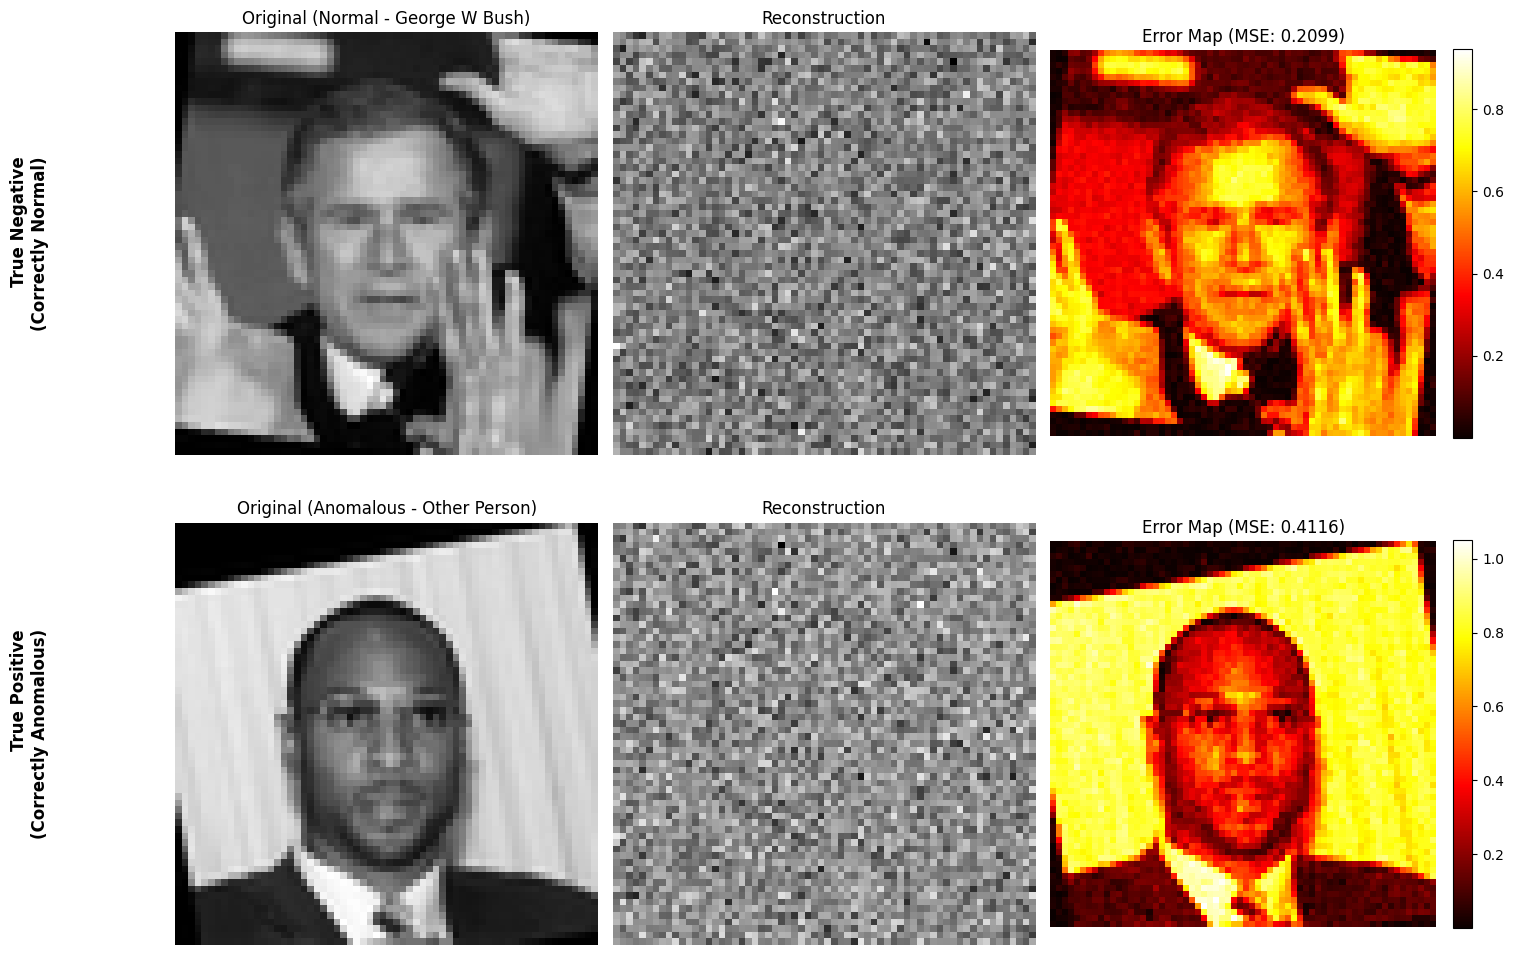

True Negative - Reconstruction Error: 0.209933
True Positive - Reconstruction Error: 0.411608
Threshold: 0.411341

Visualizing Misclassifications
False Positive - Reconstruction Error: 0.501178
False Negative - Reconstruction Error: 0.213352


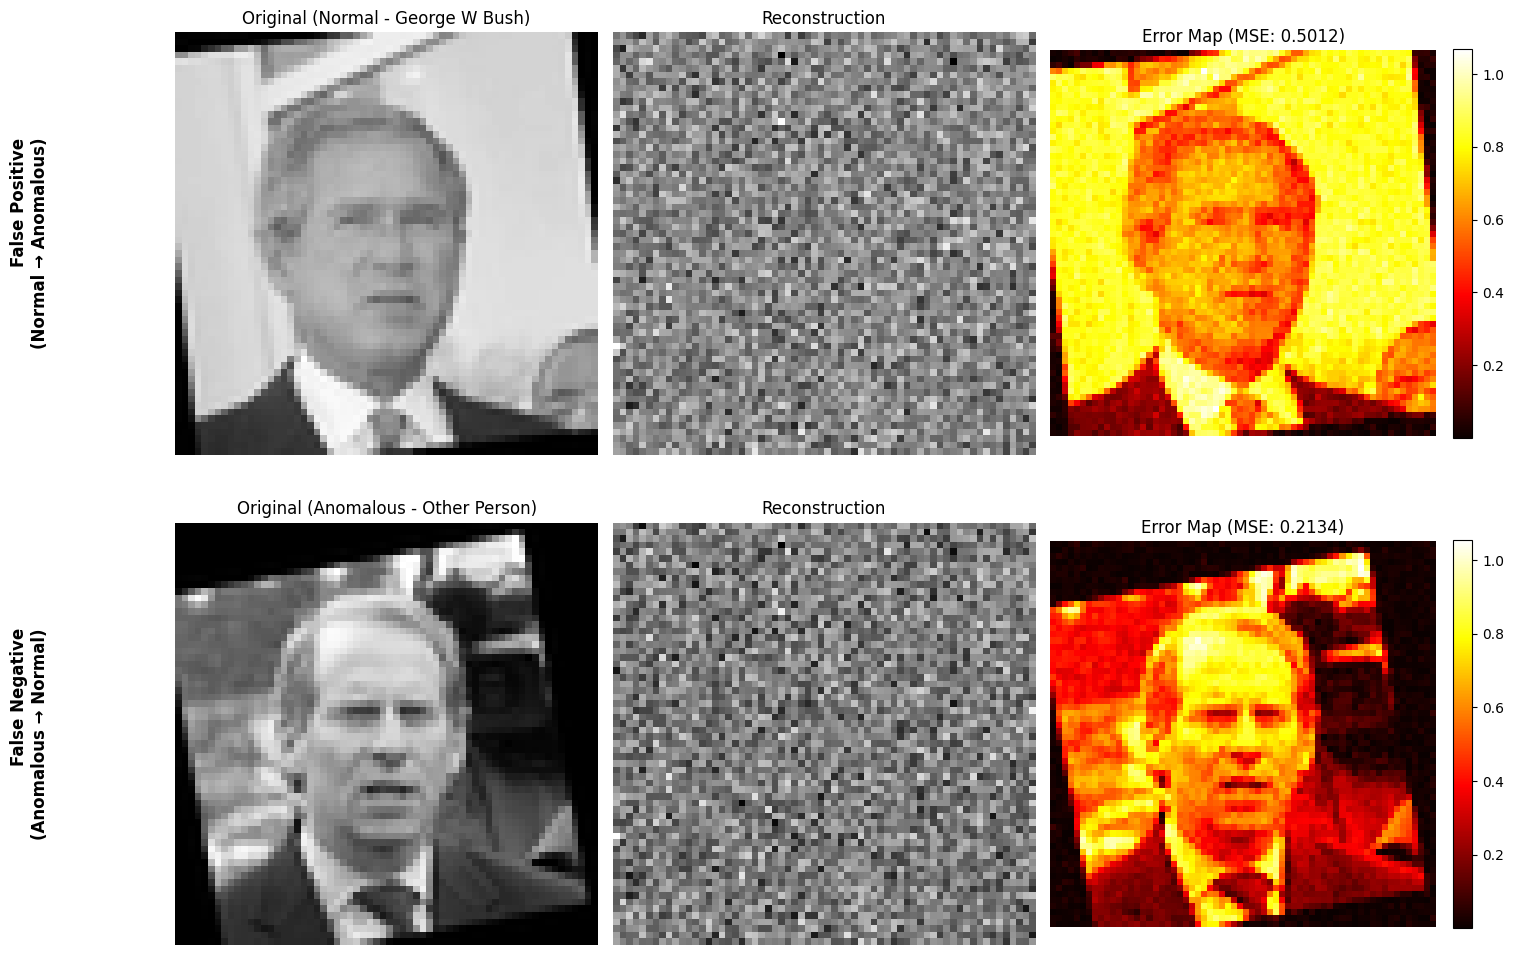


Plotting Precision-Recall Curve


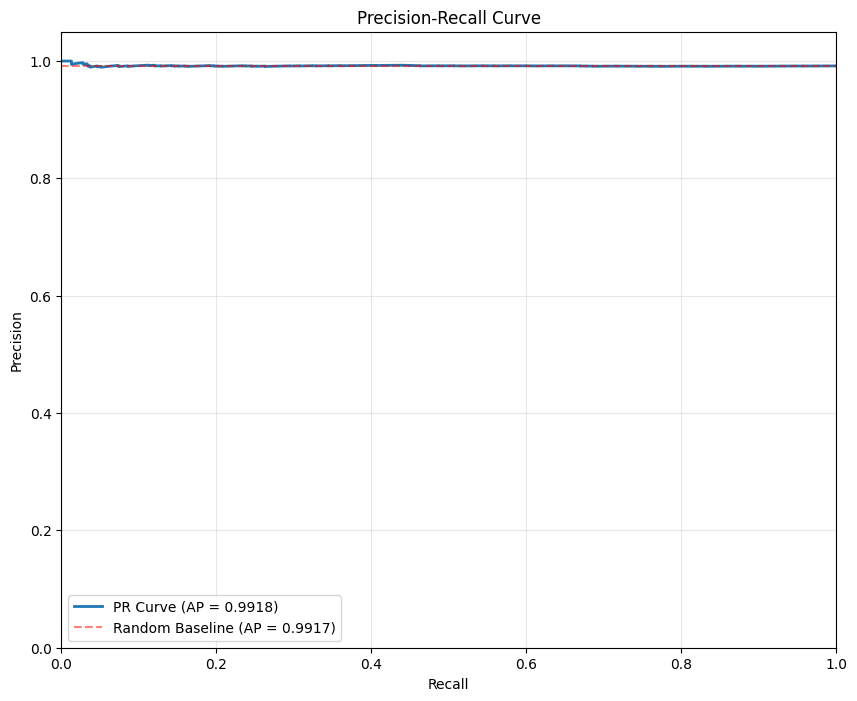

Average Precision: 0.9918
Baseline (Random): 0.9917

Reconstruction Error Distribution Analysis


/tmp/ipykernel_14129/2933859777.py:225: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = axes[0, 1].boxplot(data_to_plot, labels=labels, patch_artist=True)


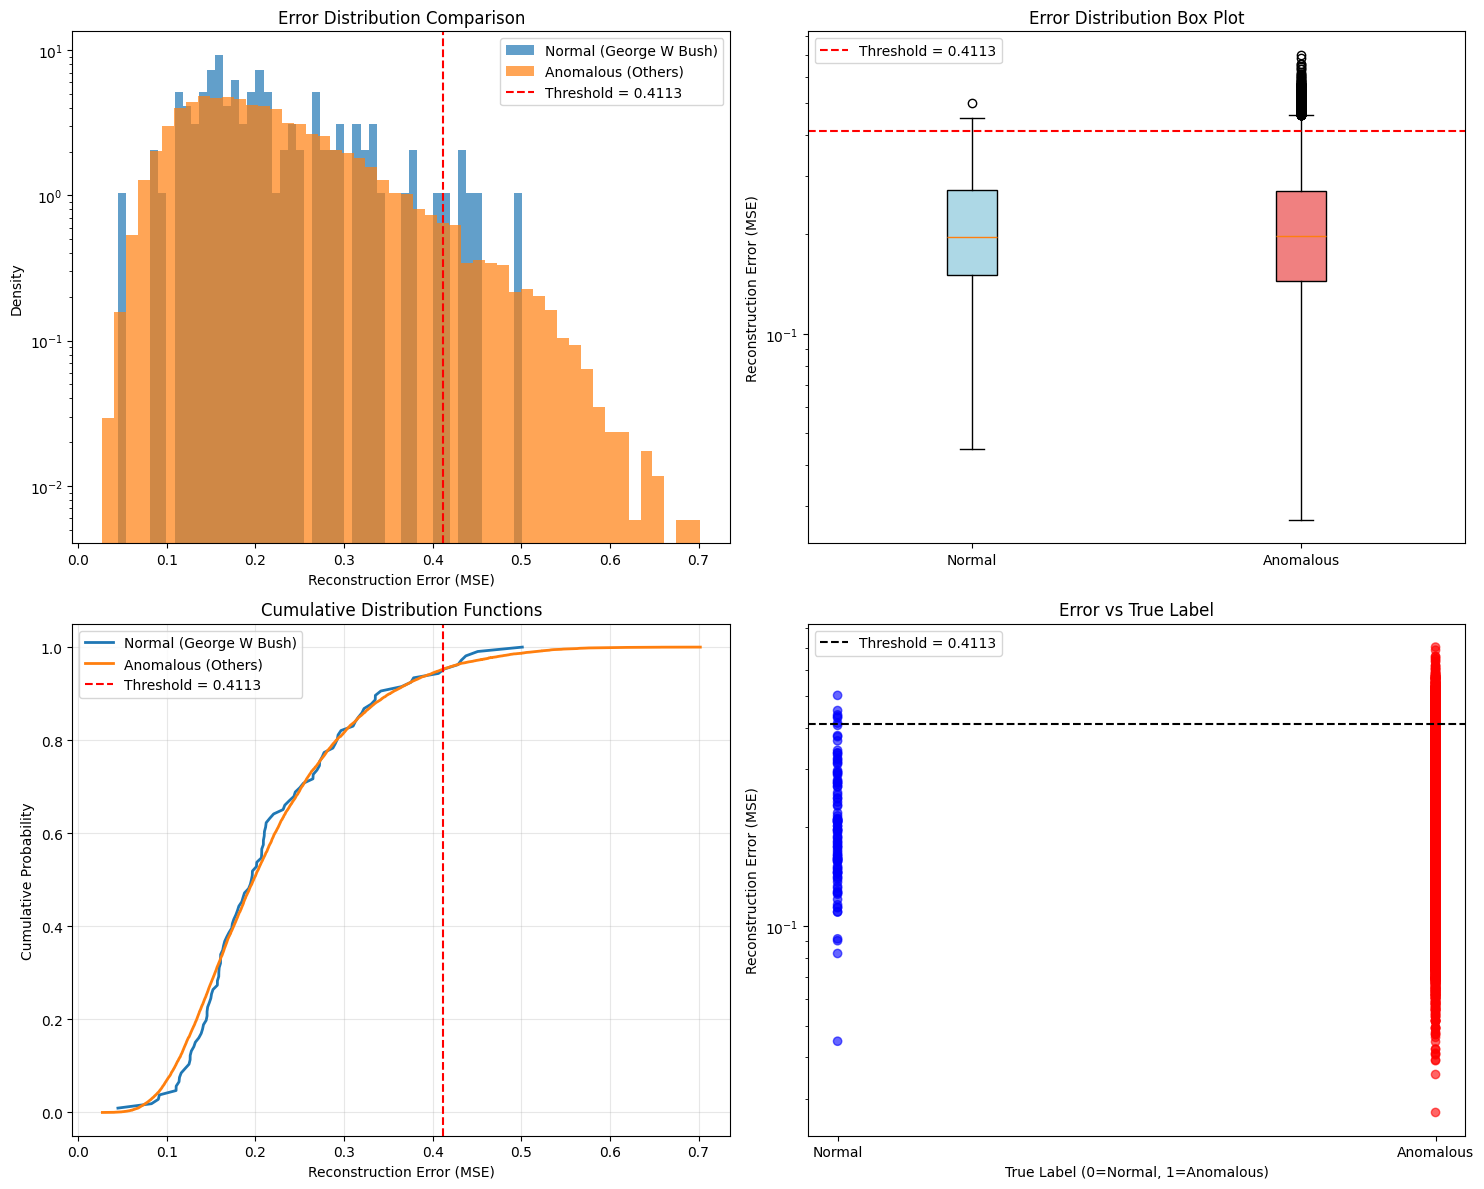

Normal Error Statistics:
  Mean: 0.217790
  Std: 0.091675
  Median: 0.195947
  95th Percentile: 0.411341

Anomalous Error Statistics:
  Mean: 0.216714
  Std: 0.097737
  Median: 0.197941
  95th Percentile: 0.408252


In [104]:
# Comprehensive Visualization of Best Model Results
class DetailedVisualizer:
    """
    Create detailed visualizations for the best anomaly detection model
    """
    def __init__(self, detector, results, test_images, test_labels):
        self.detector = detector
        self.results = results
        self.test_images = test_images
        self.test_labels = test_labels
        self.reconstruction_errors = results['reconstruction_errors']
        self.predictions = results['predictions']
    
    def visualize_correct_classifications(self):
        """Show examples of correctly classified normal and anomalous images"""
        print("Visualizing Correct Classifications")
        print("=" * 40)
        
        # Find correct classifications
        true_negatives = _np.where((self.predictions == 0) & (self.test_labels == 0))[0]  # Normal correctly identified
        true_positives = _np.where((self.predictions == 1) & (self.test_labels == 1))[0]  # Anomalous correctly identified
        
        if len(true_negatives) == 0 or len(true_positives) == 0:
            print("No correct classifications found!")
            return
        
        # Select examples
        tn_example = true_negatives[0]  # True Negative example
        tp_example = true_positives[0]  # True Positive example
        
        # Create visualization
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        # True Negative (Correctly identified normal)
        axes[0, 0].imshow(self.test_images[tn_example].reshape(64, 64), cmap='gray')
        axes[0, 0].set_title('Original (Normal - George W Bush)')
        axes[0, 0].axis('off')
        
        # Get reconstruction for TN
        tn_recon = self.detector.autoencoder.predict(self.test_images[tn_example:tn_example+1])
        axes[0, 1].imshow(tn_recon[0].reshape(64, 64), cmap='gray')
        axes[0, 1].set_title('Reconstruction')
        axes[0, 1].axis('off')
        
        # Error map for TN
        tn_error = _np.abs(self.test_images[tn_example] - tn_recon[0]).reshape(64, 64)
        im = axes[0, 2].imshow(tn_error, cmap='hot')
        axes[0, 2].set_title(f'Error Map (MSE: {self.reconstruction_errors[tn_example]:.4f})')
        axes[0, 2].axis('off')
        plt.colorbar(im, ax=axes[0, 2], fraction=0.046, pad=0.04)
        
        # True Positive (Correctly identified anomalous)
        axes[1, 0].imshow(self.test_images[tp_example].reshape(64, 64), cmap='gray')
        axes[1, 0].set_title('Original (Anomalous - Other Person)')
        axes[1, 0].axis('off')
        
        # Get reconstruction for TP
        tp_recon = self.detector.autoencoder.predict(self.test_images[tp_example:tp_example+1])
        axes[1, 1].imshow(tp_recon[0].reshape(64, 64), cmap='gray')
        axes[1, 1].set_title('Reconstruction')
        axes[1, 1].axis('off')
        
        # Error map for TP
        tp_error = _np.abs(self.test_images[tp_example] - tp_recon[0]).reshape(64, 64)
        im = axes[1, 2].imshow(tp_error, cmap='hot')
        axes[1, 2].set_title(f'Error Map (MSE: {self.reconstruction_errors[tp_example]:.4f})')
        axes[1, 2].axis('off')
        plt.colorbar(im, ax=axes[1, 2], fraction=0.046, pad=0.04)
        
        # Add row labels
        axes[0, 0].text(-0.3, 0.5, 'True Negative\n(Correctly Normal)', 
                       transform=axes[0, 0].transAxes, rotation=90, va='center', ha='right', 
                       fontweight='bold', fontsize=12)
        axes[1, 0].text(-0.3, 0.5, 'True Positive\n(Correctly Anomalous)', 
                       transform=axes[1, 0].transAxes, rotation=90, va='center', ha='right', 
                       fontweight='bold', fontsize=12)
        
        plt.tight_layout()
        plt.show()
        
        print(f"True Negative - Reconstruction Error: {self.reconstruction_errors[tn_example]:.6f}")
        print(f"True Positive - Reconstruction Error: {self.reconstruction_errors[tp_example]:.6f}")
        print(f"Threshold: {self.results['threshold']:.6f}")
    
    def visualize_misclassifications(self):
        """Show examples of misclassified images"""
        print("\nVisualizing Misclassifications")
        print("=" * 40)
        
        # Find misclassifications
        false_positives = _np.where((self.predictions == 1) & (self.test_labels == 0))[0]  # Normal classified as anomalous
        false_negatives = _np.where((self.predictions == 0) & (self.test_labels == 1))[0]  # Anomalous classified as normal
        
        if len(false_positives) == 0 and len(false_negatives) == 0:
            print("No misclassifications found!")
            return
        
        # Create visualization
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        # False Positive (Normal classified as anomalous)
        if len(false_positives) > 0:
            fp_example = false_positives[0]
            
            axes[0, 0].imshow(self.test_images[fp_example].reshape(64, 64), cmap='gray')
            axes[0, 0].set_title('Original (Normal - George W Bush)')
            axes[0, 0].axis('off')
            
            # Get reconstruction for FP
            fp_recon = self.detector.autoencoder.predict(self.test_images[fp_example:fp_example+1])
            axes[0, 1].imshow(fp_recon[0].reshape(64, 64), cmap='gray')
            axes[0, 1].set_title('Reconstruction')
            axes[0, 1].axis('off')
            
            # Error map for FP
            fp_error = _np.abs(self.test_images[fp_example] - fp_recon[0]).reshape(64, 64)
            im = axes[0, 2].imshow(fp_error, cmap='hot')
            axes[0, 2].set_title(f'Error Map (MSE: {self.reconstruction_errors[fp_example]:.4f})')
            axes[0, 2].axis('off')
            plt.colorbar(im, ax=axes[0, 2], fraction=0.046, pad=0.04)
            
            print(f"False Positive - Reconstruction Error: {self.reconstruction_errors[fp_example]:.6f}")
        else:
            for i in range(3):
                axes[0, i].text(0.5, 0.5, 'No False Positives Found', 
                               ha='center', va='center', transform=axes[0, i].transAxes)
                axes[0, i].axis('off')
        
        # False Negative (Anomalous classified as normal)
        if len(false_negatives) > 0:
            fn_example = false_negatives[0]
            
            axes[1, 0].imshow(self.test_images[fn_example].reshape(64, 64), cmap='gray')
            axes[1, 0].set_title('Original (Anomalous - Other Person)')
            axes[1, 0].axis('off')
            
            # Get reconstruction for FN
            fn_recon = self.detector.autoencoder.predict(self.test_images[fn_example:fn_example+1])
            axes[1, 1].imshow(fn_recon[0].reshape(64, 64), cmap='gray')
            axes[1, 1].set_title('Reconstruction')
            axes[1, 1].axis('off')
            
            # Error map for FN
            fn_error = _np.abs(self.test_images[fn_example] - fn_recon[0]).reshape(64, 64)
            im = axes[1, 2].imshow(fn_error, cmap='hot')
            axes[1, 2].set_title(f'Error Map (MSE: {self.reconstruction_errors[fn_example]:.4f})')
            axes[1, 2].axis('off')
            plt.colorbar(im, ax=axes[1, 2], fraction=0.046, pad=0.04)
            
            print(f"False Negative - Reconstruction Error: {self.reconstruction_errors[fn_example]:.6f}")
        else:
            for i in range(3):
                axes[1, i].text(0.5, 0.5, 'No False Negatives Found', 
                               ha='center', va='center', transform=axes[1, i].transAxes)
                axes[1, i].axis('off')
        
        # Add row labels
        axes[0, 0].text(-0.3, 0.5, 'False Positive\n(Normal → Anomalous)', 
                       transform=axes[0, 0].transAxes, rotation=90, va='center', ha='right', 
                       fontweight='bold', fontsize=12)
        axes[1, 0].text(-0.3, 0.5, 'False Negative\n(Anomalous → Normal)', 
                       transform=axes[1, 0].transAxes, rotation=90, va='center', ha='right', 
                       fontweight='bold', fontsize=12)
        
        plt.tight_layout()
        plt.show()
    
    def plot_precision_recall_curve(self):
        """Plot Precision-Recall curve"""
        print("\nPlotting Precision-Recall Curve")
        print("=" * 40)
        
        # Compute precision-recall curve
        precision, recall, thresholds = precision_recall_curve(self.test_labels, self.reconstruction_errors)
        average_precision = average_precision_score(self.test_labels, self.reconstruction_errors)
        
        # Plot PR curve
        plt.figure(figsize=(10, 8))
        plt.plot(recall, precision, linewidth=2, 
                label=f'PR Curve (AP = {average_precision:.4f})')
        
        # Add baseline (random classifier)
        baseline_precision = _np.sum(self.test_labels) / len(self.test_labels)
        plt.axhline(y=baseline_precision, color='r', linestyle='--', alpha=0.5,
                   label=f'Random Baseline (AP = {baseline_precision:.4f})')
        
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title('Precision-Recall Curve')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.show()
        
        print(f"Average Precision: {average_precision:.4f}")
        print(f"Baseline (Random): {baseline_precision:.4f}")
        
        return precision, recall, thresholds, average_precision
    
    def plot_error_distribution_analysis(self):
        """Detailed analysis of reconstruction error distributions"""
        print("\nReconstruction Error Distribution Analysis")
        print("=" * 50)
        
        normal_errors = self.results['normal_errors']
        anomalous_errors = self.results['anomalous_errors']
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # Histogram comparison
        axes[0, 0].hist(normal_errors, bins=50, alpha=0.7, label='Normal (George W Bush)', density=True)
        axes[0, 0].hist(anomalous_errors, bins=50, alpha=0.7, label='Anomalous (Others)', density=True)
        axes[0, 0].axvline(self.results['threshold'], color='red', linestyle='--', 
                          label=f'Threshold = {self.results["threshold"]:.4f}')
        axes[0, 0].set_xlabel('Reconstruction Error (MSE)')
        axes[0, 0].set_ylabel('Density')
        axes[0, 0].set_title('Error Distribution Comparison')
        axes[0, 0].legend()
        axes[0, 0].set_yscale('log')
        
        # Box plot comparison
        data_to_plot = [normal_errors, anomalous_errors]
        labels = ['Normal', 'Anomalous']
        box_plot = axes[0, 1].boxplot(data_to_plot, labels=labels, patch_artist=True)
        box_plot['boxes'][0].set_facecolor('lightblue')
        box_plot['boxes'][1].set_facecolor('lightcoral')
        axes[0, 1].axhline(y=self.results['threshold'], color='red', linestyle='--', 
                          label=f'Threshold = {self.results["threshold"]:.4f}')
        axes[0, 1].set_ylabel('Reconstruction Error (MSE)')
        axes[0, 1].set_title('Error Distribution Box Plot')
        axes[0, 1].legend()
        axes[0, 1].set_yscale('log')
        
        # Cumulative distribution
        sorted_normal = _np.sort(normal_errors)
        sorted_anomalous = _np.sort(anomalous_errors)
        normal_cdf = _np.arange(1, len(sorted_normal) + 1) / len(sorted_normal)
        anomalous_cdf = _np.arange(1, len(sorted_anomalous) + 1) / len(sorted_anomalous)
        
        axes[1, 0].plot(sorted_normal, normal_cdf, label='Normal (George W Bush)', linewidth=2)
        axes[1, 0].plot(sorted_anomalous, anomalous_cdf, label='Anomalous (Others)', linewidth=2)
        axes[1, 0].axvline(self.results['threshold'], color='red', linestyle='--', 
                          label=f'Threshold = {self.results["threshold"]:.4f}')
        axes[1, 0].set_xlabel('Reconstruction Error (MSE)')
        axes[1, 0].set_ylabel('Cumulative Probability')
        axes[1, 0].set_title('Cumulative Distribution Functions')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        # Error vs prediction scatter
        all_errors = _np.concatenate([normal_errors, anomalous_errors])
        all_labels = _np.concatenate([_np.zeros(len(normal_errors)), _np.ones(len(anomalous_errors))])
        colors = ['blue' if label == 0 else 'red' for label in all_labels]
        
        axes[1, 1].scatter(all_labels, all_errors, c=colors, alpha=0.6)
        axes[1, 1].axhline(y=self.results['threshold'], color='black', linestyle='--', 
                          label=f'Threshold = {self.results["threshold"]:.4f}')
        axes[1, 1].set_xlabel('True Label (0=Normal, 1=Anomalous)')
        axes[1, 1].set_ylabel('Reconstruction Error (MSE)')
        axes[1, 1].set_title('Error vs True Label')
        axes[1, 1].set_xticks([0, 1])
        axes[1, 1].set_xticklabels(['Normal', 'Anomalous'])
        axes[1, 1].legend()
        axes[1, 1].set_yscale('log')
        
        plt.tight_layout()
        plt.show()
        
        # Print statistics
        print(f"Normal Error Statistics:")
        print(f"  Mean: {_np.mean(normal_errors):.6f}")
        print(f"  Std: {_np.std(normal_errors):.6f}")
        print(f"  Median: {_np.median(normal_errors):.6f}")
        print(f"  95th Percentile: {_np.percentile(normal_errors, 95):.6f}")
        
        print(f"\nAnomalous Error Statistics:")
        print(f"  Mean: {_np.mean(anomalous_errors):.6f}")
        print(f"  Std: {_np.std(anomalous_errors):.6f}")
        print(f"  Median: {_np.median(anomalous_errors):.6f}")
        print(f"  95th Percentile: {_np.percentile(anomalous_errors, 95):.6f}")
    
    def run_comprehensive_visualization(self):
        """Run all visualizations"""
        print("Comprehensive Visualization of Best Model Results")
        print("=" * 60)
        
        # Correct classifications
        self.visualize_correct_classifications()
        
        # Misclassifications
        self.visualize_misclassifications()
        
        # Precision-Recall curve
        precision, recall, thresholds, ap = self.plot_precision_recall_curve()
        
        # Error distribution analysis
        self.plot_error_distribution_analysis()
        
        return {
            'precision': precision,
            'recall': recall,
            'thresholds': thresholds,
            'average_precision': ap
        }

# Run comprehensive visualization for the best model
def run_detailed_visualization():
    """Run detailed visualization for the best model"""
    print("Running Detailed Visualization for Best Model")
    print("=" * 60)
    
    # Get the best model from bottleneck analysis
    best_detector = best_model_data['detector']
    best_results = best_model_data['results']
    
    # Load test data (reuse from bottleneck analysis)
    lfw_loader = LFWLoader()
    images, labels, _ = lfw_loader.load_lfw_data()
    normal_train, test_images, test_labels = lfw_loader.split_data(images, labels, test_ratio=0.2)
    
    # Create visualizer
    visualizer = DetailedVisualizer(best_detector, best_results, test_images, test_labels)
    
    # Run comprehensive visualization
    pr_results = visualizer.run_comprehensive_visualization()
    
    return visualizer, pr_results

# Run the detailed visualization
detailed_visualizer, pr_curve_results = run_detailed_visualization()
